**Business Scenario:**<br>
You have joined an e-commerce company as a Senior Data Scientist. The marketing department wants to build a machine learning model for predicting whether customers will make another purchase. Before model building, you have been asked to clean and prepare the customer dataset.

**Structure**
* Task 1 - Dataset Understanding
* Task 2 - Data Quality Assessment
* Task 3 - Data Cleaning
* Task 4 - Data Transformation
* Task 5 - Data Reduction
* Task 6 - Proximity Measures
* Task 7 - Reflection Report
* Assignment Report - in PDF

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Task 1 - Dataset Understanding

In [2]:
pd.set_option('display.max_columns', None)

cusDS = pd.read_csv('https://raw.githubusercontent.com/swapnilsaurav/Dataset/master/mall_customer_preprocessing_dataset.csv')
cusDS.head(10)

,CustomerID,CustomerName,Age,Gender,AnnualIncome_INR,IncomeCurrency,SpendingScore_1_100,MembershipTier,JoinDate,LastPurchaseDate,VisitFrequency,AvgBasketValue_INR,TotalPurchases,OnlinePurchases,StorePurchases,PreferredCategory,City,Country,EmailProvider,DeviceType,PaymentMethod,LoyaltyPoints,SatisfactionRating_1_5,CouponUsed,ChurnNextMonth
0,CUST100001,Diya Verma,42.0,Female,241279.0,NaN,57,Silver,24-Feb-2024,14/09/2024,RARELY,758.43,40.0,3,38,Beauty,bengaluru,NaN,gmail.com,android,Credit Card,1438.0,2.0,1,0.0
1,CUST100002,Aditya Nair,52.0,male,1135484.0,Rs,61,GOLD,02/02/2025,10-Oct-2025,Weekly,2132.28,7.0,4,2,SPORTS,PUNE,INDIA,hotmail.com,NaN,NaN,865.0,1.0,1,0.0
2,CUST100003,Saanvi Kumar,27.0,M,241860.0,INR,64,Silvr,2022-05-30,2023-12-17,RARELY,2269.85,9.0,0,10,Electronic,lucknow,India,gmail.com,Mobile,UPI,2472.0,1.0,NaN,0.0
3,CUST100004,Vihaan Iyer,27.0,FEMALE,470187.0,INR,86,Silver,01-31-2024,18-Jul-2024,RARELY,723.67,30.0,29,1,Food Court,Pune,NaN,gmail.com,android,Credit Card,1700.0,3.0,NaN,0.0
4,CUST100005,Krishna Rao,25.0,M,630873.0,INR,53,basic,2022-01-25,01-May-2022,Monthly,12062.69,38.0,21,17,Fashion,Bengaluru,India,hotmail.com,Web,CREDIT CARD,1203.0,2.0,1,0.0
5,CUST100006,Vihaan Iyer,41.0,MALE,25000000.0,INR,51,NaN,2021-04-30,12-14-2022,Monthly,957.19,10.0,4,7,gaming,KOLKATA,INDIA,gmail.com,android,Wallet,2332.0,1.0,N,0.0
6,CUST100007,Reyansh Mehta,9.0,female,844350.0,INR,68,Silver,11-20-2021,2023-02-11,weekly,3903.16,13.0,6,7,Home Decor,Pune,india,outlook.com,IOS,Debit Card,1182.0,1.0,N,0.0
7,CUST100008,Sai Mishra,27.0,M,693450.0,₹,50,GOLD,2023-01-17,04-11-2025,RARELY,1638.04,0.0,0,0,food court,Kolkata,NaN,yahoo.com,Desktop,UPI,855.0,2.0,N,0.0
8,CUST100009,Myra Nair,22.0,Female,1020287.0,₹,88,PLATINUM,06-Aug-2024,01-09-2026,weekly,999999.00,9.0,2,6,food court,AHMEDABAD,India,gmail.com,web,Credit Card,553.0,NaN,NaN,0.0
9,CUST100010,Ishaan Chopra,49.0,Female,821121.0,Rs,41,GOLD,2024-01-28,05-30-2026,NaN,2226.43,19.0,7,12,food court,Pune,INDIA,outlook.com,Android,UPI,1057.0,5.0,Y,0.0


## 1.1 Dimensions

In [3]:
cusDS.shape

(2200, 25)

In [4]:
print(f'Number of Rows: {cusDS.shape[0]}')
print(f'Number of Columns: {cusDS.shape[1]}')

Number of Rows: 2200
Number of Columns: 25


## 1.2 Attribute Names

In [5]:
print(cusDS.columns)

Index(['CustomerID', 'CustomerName', 'Age', 'Gender', 'AnnualIncome_INR',
       'IncomeCurrency', 'SpendingScore_1_100', 'MembershipTier', 'JoinDate',
       'LastPurchaseDate', 'VisitFrequency', 'AvgBasketValue_INR',
       'TotalPurchases', 'OnlinePurchases', 'StorePurchases',
       'PreferredCategory', 'City', 'Country', 'EmailProvider', 'DeviceType',
       'PaymentMethod', 'LoyaltyPoints', 'SatisfactionRating_1_5',
       'CouponUsed', 'ChurnNextMonth'],
      dtype='object')


In [6]:
print("Attribute Names: ")
for i in cusDS.columns:
    print(i)

Attribute Names: 
CustomerID
CustomerName
Age
Gender
AnnualIncome_INR
IncomeCurrency
SpendingScore_1_100
MembershipTier
JoinDate
LastPurchaseDate
VisitFrequency
AvgBasketValue_INR
TotalPurchases
OnlinePurchases
StorePurchases
PreferredCategory
City
Country
EmailProvider
DeviceType
PaymentMethod
LoyaltyPoints
SatisfactionRating_1_5
CouponUsed
ChurnNextMonth


## 1.3 Attribute Types

**Understanding the Data Types to better understand the Attributes, for Attribute type Classification.**

In [7]:
print(cusDS.dtypes)

CustomerID                 object
CustomerName               object
Age                       float64
Gender                     object
AnnualIncome_INR          float64
IncomeCurrency             object
SpendingScore_1_100         int64
MembershipTier             object
JoinDate                   object
LastPurchaseDate           object
VisitFrequency             object
AvgBasketValue_INR        float64
TotalPurchases            float64
OnlinePurchases             int64
StorePurchases              int64
PreferredCategory          object
City                       object
Country                    object
EmailProvider              object
DeviceType                 object
PaymentMethod              object
LoyaltyPoints             float64
SatisfactionRating_1_5    float64
CouponUsed                 object
ChurnNextMonth            float64
dtype: object


**Identifying and Categorization Attributes**

In [8]:
Nominal = ['CustomerID', 'CustomerName', 'Gender', 'IncomeCurrency', 'PreferredCategory', 'City', 'Country', 'EmailProvider', 'DeviceType', 'PaymentMethod', 'CouponUsed']
Ordinal = ['SpendingScore_1_100', 'MembershipTier', 'SatisfactionRating_1_5', 'VisitFrequency']
Interval = ['JoinDate', 'LastPurchaseDate']
Ratio = ['Age', 'AnnualIncome_INR', 'AvgBasketValue_INR', 'TotalPurchases', 'OnlinePurchases', 'StorePurchases', 'LoyaltyPoints']
target =  ['ChurnNextMonth']

In [9]:
columns = []
types = []

for col in Nominal:
    columns.append(col)
    types.append('Nominal')

for col in Ordinal:
    columns.append(col)
    types.append('Ordinal')

for col in Interval:
    columns.append(col)
    types.append('Interval')

for col in Ratio:
    columns.append(col)
    types.append('Ratio')

for col in target:
    columns.append(col)
    types.append('Target')

attribute_types_df = pd.DataFrame({'Attribute': columns, 'Type': types})

current_column_order = cusDS.columns.tolist()
attribute_types_df_ordered = attribute_types_df.set_index('Attribute').reindex(current_column_order).reset_index()
print("Attribute Types:")
display(attribute_types_df_ordered)

Attribute Types:


,Attribute,Type
0,CustomerID,Nominal
1,CustomerName,Nominal
2,Age,Ratio
3,Gender,Nominal
4,AnnualIncome_INR,Ratio
5,IncomeCurrency,Nominal
6,SpendingScore_1_100,Ordinal
7,MembershipTier,Ordinal
8,JoinDate,Interval
9,LastPurchaseDate,Interval


**Count of each Attribute Type**

In [10]:
print("Count of each Attribute Type:")
attribute_types_df_ordered.value_counts('Type')

Count of each Attribute Type:


,count
Type,
Nominal,11
Ratio,7
Ordinal,4
Interval,2
Target,1


## 1.4 First Five Records

In [11]:
print("First Five Records: ")
cusDS.head()

First Five Records: 


,CustomerID,CustomerName,Age,Gender,AnnualIncome_INR,IncomeCurrency,SpendingScore_1_100,MembershipTier,JoinDate,LastPurchaseDate,VisitFrequency,AvgBasketValue_INR,TotalPurchases,OnlinePurchases,StorePurchases,PreferredCategory,City,Country,EmailProvider,DeviceType,PaymentMethod,LoyaltyPoints,SatisfactionRating_1_5,CouponUsed,ChurnNextMonth
0,CUST100001,Diya Verma,42.0,Female,241279.0,NaN,57,Silver,24-Feb-2024,14/09/2024,RARELY,758.43,40.0,3,38,Beauty,bengaluru,NaN,gmail.com,android,Credit Card,1438.0,2.0,1,0.0
1,CUST100002,Aditya Nair,52.0,male,1135484.0,Rs,61,GOLD,02/02/2025,10-Oct-2025,Weekly,2132.28,7.0,4,2,SPORTS,PUNE,INDIA,hotmail.com,NaN,NaN,865.0,1.0,1,0.0
2,CUST100003,Saanvi Kumar,27.0,M,241860.0,INR,64,Silvr,2022-05-30,2023-12-17,RARELY,2269.85,9.0,0,10,Electronic,lucknow,India,gmail.com,Mobile,UPI,2472.0,1.0,NaN,0.0
3,CUST100004,Vihaan Iyer,27.0,FEMALE,470187.0,INR,86,Silver,01-31-2024,18-Jul-2024,RARELY,723.67,30.0,29,1,Food Court,Pune,NaN,gmail.com,android,Credit Card,1700.0,3.0,NaN,0.0
4,CUST100005,Krishna Rao,25.0,M,630873.0,INR,53,basic,2022-01-25,01-May-2022,Monthly,12062.69,38.0,21,17,Fashion,Bengaluru,India,hotmail.com,Web,CREDIT CARD,1203.0,2.0,1,0.0


## 1.5 Descriptive Statistics

**Numerical Attributes**

In [12]:
print("Descriptive Statistics (Numerical attributes): ")
cusDS.describe()

Descriptive Statistics (Numerical attributes): 


,Age,AnnualIncome_INR,SpendingScore_1_100,AvgBasketValue_INR,TotalPurchases,OnlinePurchases,StorePurchases,LoyaltyPoints,SatisfactionRating_1_5,ChurnNextMonth
count,2096.000000,2.059000e+03,2200.00000,2172.000000,2189.000000,2200.000000,2200.000000,2188.000000,2170.000000,2173.000000
mean,34.781966,1.706644e+06,53.90000,13356.393485,90.349018,8.139091,9.426364,8949.128428,3.137327,0.208928
std,18.054272,9.558517e+06,21.44778,104332.718769,850.619369,11.089110,11.598287,87720.316207,1.697376,0.406636
min,-5.000000,-5.000000e+04,1.00000,-250.000000,-3.000000,0.000000,0.000000,-50.000000,0.000000,0.000000
25%,26.000000,4.423870e+05,39.00000,1083.787500,5.000000,1.000000,2.000000,747.750000,2.000000,0.000000
50%,33.000000,6.511680e+05,54.00000,1814.650000,12.000000,4.000000,5.000000,1199.000000,3.000000,0.000000
75%,42.000000,9.591475e+05,68.00000,3044.790000,25.000000,11.000000,13.000000,1618.750000,4.000000,0.000000
max,180.000000,1.000000e+08,100.00000,999999.000000,9999.000000,104.000000,110.000000,999999.000000,11.000000,1.000000


**Categorical and Date Attributes**

In [13]:
print("Descriptive Statistics (Non-Numerical attributes): ")
cusDS.describe(include='object')

Descriptive Statistics (Non-Numerical attributes): 


,CustomerID,CustomerName,Gender,IncomeCurrency,MembershipTier,JoinDate,LastPurchaseDate,VisitFrequency,PreferredCategory,City,Country,EmailProvider,DeviceType,PaymentMethod,CouponUsed
count,2200,2200,1970,1882,1957,2200,2124,1941,2200,2184,1838,1972,1946,1980,1935
unique,2087,556,9,4,9,1830,1781,7,44,36,5,8,8,8,8
top,CUST100340,Rahul Mehta,MALE,INR,Gold,not available,10-19-2024,Monthly,Fashion,Chennai,Bharat,gmail.com,IOS,upi,yes
freq,4,12,240,962,247,11,5,302,69,86,392,277,259,269,249


**All Attributes**

In [14]:
print("Descriptive Statistics (All attributes): ")
cusDS.describe(include='all')

Descriptive Statistics (All attributes): 


,CustomerID,CustomerName,Age,Gender,AnnualIncome_INR,IncomeCurrency,SpendingScore_1_100,MembershipTier,JoinDate,LastPurchaseDate,VisitFrequency,AvgBasketValue_INR,TotalPurchases,OnlinePurchases,StorePurchases,PreferredCategory,City,Country,EmailProvider,DeviceType,PaymentMethod,LoyaltyPoints,SatisfactionRating_1_5,CouponUsed,ChurnNextMonth
count,2200,2200,2096.000000,1970,2.059000e+03,1882,2200.00000,1957,2200,2124,1941,2172.000000,2189.000000,2200.000000,2200.000000,2200,2184,1838,1972,1946,1980,2188.000000,2170.000000,1935,2173.000000
unique,2087,556,NaN,9,NaN,4,NaN,9,1830,1781,7,NaN,NaN,NaN,NaN,44,36,5,8,8,8,NaN,NaN,8,NaN
top,CUST100340,Rahul Mehta,NaN,MALE,NaN,INR,NaN,Gold,not available,10-19-2024,Monthly,NaN,NaN,NaN,NaN,Fashion,Chennai,Bharat,gmail.com,IOS,upi,NaN,NaN,yes,NaN
freq,4,12,NaN,240,NaN,962,NaN,247,11,5,302,NaN,NaN,NaN,NaN,69,86,392,277,259,269,NaN,NaN,249,NaN
mean,NaN,NaN,34.781966,NaN,1.706644e+06,NaN,53.90000,NaN,NaN,NaN,NaN,13356.393485,90.349018,8.139091,9.426364,NaN,NaN,NaN,NaN,NaN,NaN,8949.128428,3.137327,NaN,0.208928
std,NaN,NaN,18.054272,NaN,9.558517e+06,NaN,21.44778,NaN,NaN,NaN,NaN,104332.718769,850.619369,11.089110,11.598287,NaN,NaN,NaN,NaN,NaN,NaN,87720.316207,1.697376,NaN,0.406636
min,NaN,NaN,-5.000000,NaN,-5.000000e+04,NaN,1.00000,NaN,NaN,NaN,NaN,-250.000000,-3.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,-50.000000,0.000000,NaN,0.000000
25%,NaN,NaN,26.000000,NaN,4.423870e+05,NaN,39.00000,NaN,NaN,NaN,NaN,1083.787500,5.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,747.750000,2.000000,NaN,0.000000
50%,NaN,NaN,33.000000,NaN,6.511680e+05,NaN,54.00000,NaN,NaN,NaN,NaN,1814.650000,12.000000,4.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,1199.000000,3.000000,NaN,0.000000
75%,NaN,NaN,42.000000,NaN,9.591475e+05,NaN,68.00000,NaN,NaN,NaN,NaN,3044.790000,25.000000,11.000000,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,1618.750000,4.000000,NaN,0.000000


## 1.6 Identifying Numerical and Categorical Attributes

**Attributes Numerical & Categorical**

In [15]:
print("Numerical Attributes: ")
print(cusDS.select_dtypes(include=np.number).columns)
print(" ")
print("Categorical Attributes: ")
print(cusDS.select_dtypes(include='object').columns)

Numerical Attributes: 
Index(['Age', 'AnnualIncome_INR', 'SpendingScore_1_100', 'AvgBasketValue_INR',
       'TotalPurchases', 'OnlinePurchases', 'StorePurchases', 'LoyaltyPoints',
       'SatisfactionRating_1_5', 'ChurnNextMonth'],
      dtype='object')
 
Categorical Attributes: 
Index(['CustomerID', 'CustomerName', 'Gender', 'IncomeCurrency',
       'MembershipTier', 'JoinDate', 'LastPurchaseDate', 'VisitFrequency',
       'PreferredCategory', 'City', 'Country', 'EmailProvider', 'DeviceType',
       'PaymentMethod', 'CouponUsed'],
      dtype='object')


*We notice that the 'ChurnNextMonth' attribute which is the Target attribute is been parsed as Numeric attribute but it actually should be a Categorical Binary Attribute*

**Numerical Columns**

*We have excluded the 'ChurnNextMonth' attribute as it is not a numerical attribute*

In [16]:
cusDS[cusDS.select_dtypes(include=np.number).columns[:-1]].head()

,Age,AnnualIncome_INR,SpendingScore_1_100,AvgBasketValue_INR,TotalPurchases,OnlinePurchases,StorePurchases,LoyaltyPoints,SatisfactionRating_1_5
0,42.0,241279.0,57,758.43,40.0,3,38,1438.0,2.0
1,52.0,1135484.0,61,2132.28,7.0,4,2,865.0,1.0
2,27.0,241860.0,64,2269.85,9.0,0,10,2472.0,1.0
3,27.0,470187.0,86,723.67,30.0,29,1,1700.0,3.0
4,25.0,630873.0,53,12062.69,38.0,21,17,1203.0,2.0


**Categorical & Date-Time Columens**

In [17]:
cusDS[cusDS.select_dtypes(include='object').columns].head()

,CustomerID,CustomerName,Gender,IncomeCurrency,MembershipTier,JoinDate,LastPurchaseDate,VisitFrequency,PreferredCategory,City,Country,EmailProvider,DeviceType,PaymentMethod,CouponUsed
0,CUST100001,Diya Verma,Female,NaN,Silver,24-Feb-2024,14/09/2024,RARELY,Beauty,bengaluru,NaN,gmail.com,android,Credit Card,1
1,CUST100002,Aditya Nair,male,Rs,GOLD,02/02/2025,10-Oct-2025,Weekly,SPORTS,PUNE,INDIA,hotmail.com,NaN,NaN,1
2,CUST100003,Saanvi Kumar,M,INR,Silvr,2022-05-30,2023-12-17,RARELY,Electronic,lucknow,India,gmail.com,Mobile,UPI,NaN
3,CUST100004,Vihaan Iyer,FEMALE,INR,Silver,01-31-2024,18-Jul-2024,RARELY,Food Court,Pune,NaN,gmail.com,android,Credit Card,NaN
4,CUST100005,Krishna Rao,M,INR,basic,2022-01-25,01-May-2022,Monthly,Fashion,Bengaluru,India,hotmail.com,Web,CREDIT CARD,1


**Count of Numerical and Categorical Attributes**

In [18]:
print("Count of Numerical Attributes: ", cusDS.select_dtypes(include=np.number).columns[:-1].size)
print("Count of Categorical/Date-Time Attributes: ", cusDS.select_dtypes(include='object').columns.size)
print("Target Attribute: 1 (ChurnNextMonth) ")

Count of Numerical Attributes:  9
Count of Categorical/Date-Time Attributes:  15
Target Attribute: 1 (ChurnNextMonth) 


## Deliverables:


1.   The Customer Dataset is a large dataset of `2200 rows` and `25 Columens`.
2.   Data Set consists of `11` Nominal, `7` Ratio, `4` Ordinal and `2` Interval Attributes along with `1` Target Attribute.
3.   Initial inspection of the descriptive statistics also reveals potential data quality concerns (e.g., negative values in Age/Income, unrealistic maximums such as 999999 in LoyaltyPoints/TotalPurchases, and negative AvgBasketValue). These will be investigated systematically in Task 2
4.   While Classifying the attributes in Numerical amd Categorical types we see that the Target attribute 'ChurnNextMonth' is been parsed as a Float, which led it to be classfied as Numerical by the 'select_dtypes()' Api. However by observation we come to know the wrong classification due to the wrong Data-Type problem. <br> In reality there are `9 Numerical Attributes` and `16 Categorical/Date-Time Attributes`, including the Target 'ChurnNextMonth' Attribute.
5.   We will Fix the problametic Data Types in the Further Tasks along with other Problems.    






# Task 2 - Data Quality Assessment

## 2.1 Identifying Missing Values

In [19]:
print("Missing Values & Missing Values (%) per Column:")
missing = cusDS.isnull().sum()
missing_pct = (cusDS.isnull().sum() / len(cusDS) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Missing %': missing_pct})
missing_df.sort_values('Missing %', ascending=False)



Missing Values & Missing Values (%) per Column:


,Missing,Missing %
Country,362,16.45
IncomeCurrency,318,14.45
CouponUsed,265,12.05
VisitFrequency,259,11.77
DeviceType,254,11.55
MembershipTier,243,11.05
Gender,230,10.45
EmailProvider,228,10.36
PaymentMethod,220,10.00
AnnualIncome_INR,141,6.41


## 2.2 Identifying Duplicate records

In [20]:
# Full row duplicates
print("Fully duplicated rows:", cusDS.duplicated().sum())

# Duplicate CustomerIDs
print("Duplicate CustomerIDs:", cusDS['CustomerID'].duplicated().sum())

# Sample of the duplicate CustomerID rows if any exist, to see if they're exact dupes or conflicting records
dupe_ids = cusDS[cusDS['CustomerID'].duplicated(keep=False)]
print("\nSample of duplicate CustomerID records:")
dupe_ids.sort_values('CustomerID').head(10)

Fully duplicated rows: 64
Duplicate CustomerIDs: 113

Sample of duplicate CustomerID records:


,CustomerID,CustomerName,Age,Gender,AnnualIncome_INR,IncomeCurrency,SpendingScore_1_100,MembershipTier,JoinDate,LastPurchaseDate,VisitFrequency,AvgBasketValue_INR,TotalPurchases,OnlinePurchases,StorePurchases,PreferredCategory,City,Country,EmailProvider,DeviceType,PaymentMethod,LoyaltyPoints,SatisfactionRating_1_5,CouponUsed,ChurnNextMonth
3,CUST100004,Vihaan Iyer,27.0,FEMALE,470187.0,INR,86,Silver,01-31-2024,18-Jul-2024,RARELY,723.67,30.0,29,1,Food Court,Pune,NaN,gmail.com,android,Credit Card,1700.0,3.0,NaN,0.0
120,CUST100004,Aditya Reddy,46.0,female,645689.0,INR,56,Platinum,2024-05-16,20/01/2026,Rarely,1617.92,12.0,2,11,GAMING,Hyderabad,NaN,gmail.com,Android,Credit Card,2440.0,3.0,yes,0.0
10,CUST100011,Sai Sinha,11.0,FEMALE,837540.0,NaN,67,Basic,26-Nov-2024,2026-05-10,monthly,283.96,9.0,1,7,Kids,Bangalore,india,company.com,iOS,Wallet,412.0,4.0,NaN,0.0
127,CUST100011,Sai Sinha,11.0,FEMALE,837540.0,NaN,67,Basic,26-Nov-2024,2026-05-10,monthly,283.96,9.0,1,7,Kids,Bangalore,india,company.com,iOS,Wallet,412.0,4.0,NaN,0.0
129,CUST100016,Aadhya Khan,25.0,FEMALE,213481.0,INR,23,silver,12/09/2022,09-26-2022,NaN,1194.35,16.0,15,1,Fashion,Mumbay,India,gmail.com,Web,Debit Card,613.0,1.0,0,0.0
15,CUST100016,Aadhya Khan,25.0,FEMALE,213481.0,INR,23,silver,12/09/2022,09-26-2022,NaN,1194.35,16.0,15,1,Fashion,Mumbay,India,gmail.com,Web,Debit Card,613.0,1.0,0,0.0
103,CUST100018,Saanvi Rao,31.0,FEMALE,NaN,INR,32,NaN,2021-06-14,16-Feb-2023,Weekly,1802.16,6.0,2,4,Fashion,bengaluru,IN,gmail.com,web,Credit Card,1472.0,3.0,Y,0.0
17,CUST100018,Saanvi Rao,31.0,FEMALE,NaN,INR,32,NaN,2021-06-14,16-Feb-2023,Weekly,1802.16,6.0,2,4,Fashion,bengaluru,IN,gmail.com,web,Credit Card,1472.0,3.0,Y,0.0
431,CUST100019,Ayaan Patel,20.0,FEMALE,99999999.0,INR,65,Silvr,09/01/2025,07-16-2025,Daily,5204.33,16.0,4,12,sports,NaN,INDIA,gmail.com,Mobile,upi,1232.0,1.0,N,0.0
18,CUST100019,Sara Patel,27.0,Other,1254616.0,NaN,100,Gold,28-Nov-2023,02-Dec-2024,NaN,1709.26,6.0,1,6,Electronics,ahmedabad,india,NaN,IOS,CREDIT CARD,1511.0,5.0,Yes,0.0


***We see 2 types of Duplucate Values:***<br><br>
**Category A**— True duplicates (same CustomerID, identical data in every column):

CUST100011 (Sai Sinha, rows 10 & 127)<br>
*They are Redundant, safe to Drop*<br><br>
**Category B** — ID collisions (same CustomerID, but different customers with conflicting data):

CUST100004 -- Vihaan Iyer (age 27, income 470187) vs Aditya Reddy (age 46, income 645689)<br>
*These are not duplicates in the data-cleaning sense. They could be data integrity/generation issue where the same ID got assigned to two different people*


In [21]:
# Category A: exact duplicate rows among duplicate CustomerIDs
exact_dupe_mask = cusDS.duplicated(keep=False) & cusDS.duplicated(subset=['CustomerID'], keep=False)
exact_dupes = cusDS[exact_dupe_mask]
print("Rows that are FULL exact duplicates (same ID + same everything):", exact_dupes['CustomerID'].nunique(), "unique IDs involved")

# Category B: same CustomerID but NOT same rows -- ID collisions
colliding_mask = cusDS['CustomerID'].duplicated(keep=False) & ~cusDS.duplicated(keep=False)
colliding = cusDS[colliding_mask]
print("Rows with COLLIDING CustomerID (same ID, different data):", colliding['CustomerID'].nunique(), "unique IDs involved")
print("Total rows affected by ID collisions:", colliding.shape[0])

# Sanity check: these two counts should add up to the total duplicate CustomerID rows
print("\nCheck:", exact_dupes.shape[0] + colliding.shape[0], "vs total dup rows:", cusDS[cusDS['CustomerID'].duplicated(keep=False)].shape[0])

Rows that are FULL exact duplicates (same ID + same everything): 59 unique IDs involved
Rows with COLLIDING CustomerID (same ID, different data): 47 unique IDs involved
Total rows affected by ID collisions: 93

Check: 216 vs total dup rows: 216


## 2.3 Identifying Inconsistent categorical values

*ChurnNextMonth should manually added to the categorical check despite its float dtype, because Task 1 analysis already identified it as a mis-typed categorical variable.*

In [22]:
categorical_cols = list(cusDS.select_dtypes(include='object').columns) + ['ChurnNextMonth']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(cusDS[col].value_counts(dropna=False))


--- CustomerID ---
CustomerID
CUST100340    4
CUST100268    3
CUST100132    3
CUST101160    3
CUST100564    3
             ..
CUST100776    1
CUST100775    1
CUST100774    1
CUST100773    1
CUST100788    1
Name: count, Length: 2087, dtype: int64

--- CustomerName ---
CustomerName
Rahul Mehta         12
Priya Kumar         11
Ishaan Mishra       10
Riya Nair           10
Vihaan Joshi        10
                    ..
Ayaan Kapoor         1
 Reyansh Sinha       1
 Reyansh Mishra      1
 Kiara Mehta         1
 Vivaan Verma        1
Name: count, Length: 556, dtype: int64

--- Gender ---
Gender
MALE      240
NaN       230
female    228
M         222
Other     221
Female    220
FEMALE    220
F         218
male      201
Male      200
Name: count, dtype: int64

--- IncomeCurrency ---
IncomeCurrency
INR    962
USD    324
NaN    318
₹      307
Rs     289
Name: count, dtype: int64

--- MembershipTier ---
MembershipTier
Gold        247
PLATINUM    245
Platinum    245
NaN         243
Silver      22



*   Attributes like CustomerID and CustomerName are expected to have high cardinality.
*   Even Excluding them, almost all other Attributes have Inconsistent Values.
*   We even spot some Invalid entries, which we will look in detail further.




##  2.4 Identifying Outliers

In [23]:
print("Numerical Attributes: ") #From 1.6
print(cusDS.select_dtypes(include=np.number).columns)

Numerical Attributes: 
Index(['Age', 'AnnualIncome_INR', 'SpendingScore_1_100', 'AvgBasketValue_INR',
       'TotalPurchases', 'OnlinePurchases', 'StorePurchases', 'LoyaltyPoints',
       'SatisfactionRating_1_5', 'ChurnNextMonth'],
      dtype='object')


*We Exclude 'ChurnNextMonth' as we alrady know from Task 1 that it is a mis-typed Categorical Attribute*

**IQR-Based Approach**

In [24]:
num_cols = ['Age', 'AnnualIncome_INR', 'SpendingScore_1_100', 'AvgBasketValue_INR',
            'TotalPurchases', 'OnlinePurchases', 'StorePurchases', 'LoyaltyPoints',
            'SatisfactionRating_1_5']

for col in num_cols:
    Q1 = cusDS[col].quantile(0.25)
    Q3 = cusDS[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = cusDS[(cusDS[col] < lower) | (cusDS[col] > upper)]

    print(f"--- {col} ---")
    print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
    print(f"Lower bound={lower:.2f}, Upper bound={upper:.2f}")
    print(f"Number of outliers: {outliers.shape[0]}")
    print(f"Min value: {cusDS[col].min()}, Max value: {cusDS[col].max()}")
    print()

--- Age ---
Q1=26.0, Q3=42.0, IQR=16.0
Lower bound=2.00, Upper bound=66.00
Number of outliers: 63
Min value: -5.0, Max value: 180.0

--- AnnualIncome_INR ---
Q1=442387.0, Q3=959147.5, IQR=516760.5
Lower bound=-332753.75, Upper bound=1734288.25
Number of outliers: 87
Min value: -50000.0, Max value: 99999999.0

--- SpendingScore_1_100 ---
Q1=39.0, Q3=68.0, IQR=29.0
Lower bound=-4.50, Upper bound=111.50
Number of outliers: 0
Min value: 1, Max value: 100

--- AvgBasketValue_INR ---
Q1=1083.7875000000001, Q3=3044.79, IQR=1961.0024999999998
Lower bound=-1857.72, Upper bound=5986.29
Number of outliers: 139
Min value: -250.0, Max value: 999999.0

--- TotalPurchases ---
Q1=5.0, Q3=25.0, IQR=20.0
Lower bound=-25.00, Upper bound=55.00
Number of outliers: 111
Min value: -3.0, Max value: 9999.0

--- OnlinePurchases ---
Q1=1.0, Q3=11.0, IQR=10.0
Lower bound=-14.00, Upper bound=26.00
Number of outliers: 145
Min value: 0, Max value: 104

--- StorePurchases ---
Q1=2.0, Q3=13.0, IQR=11.0
Lower bound=-14

*Several columns show suspiciously large extreme max values that look like placeholder, not genuine extreme customers. These aren't really statistical outliers, they are Invalid Entries Disgised as Outliers.*<br>
**Like:**


*   AnnualIncome_INR, Max value: 99999999.0
*   Age, Max value: 180.0<br><br>

**Assumption:** <br>
Assuming that the Extreme and Invalid values seen in the data are Placeholder values, which means these values would only be Maximum and Minimum of the data.<br>
We would use the Percentile-based approach to look at the 1st and the 99th percentile, to access if they are still resonable.  




**Percentile-Based Approach**

1st & 99th Percentile

In [25]:
for col in num_cols:
    p1 = cusDS[col].quantile(0.01)
    p99 = cusDS[col].quantile(0.99)
    print(f"{col}: 1st percentile= {p1}, 99th percentile= {p99}")
    print("")

Age: 1st percentile= 0.0, 99th percentile= 122.0

AnnualIncome_INR: 1st percentile= 146444.52000000002, 99th percentile= 25000000.0

SpendingScore_1_100: 1st percentile= 3.980000000000004, 99th percentile= 100.0

AvgBasketValue_INR: 1st percentile= -250.0, 99th percentile= 999999.0

TotalPurchases: 1st percentile= 0.0, 99th percentile= 96.35999999999967

OnlinePurchases: 1st percentile= 0.0, 99th percentile= 55.0

StorePurchases: 1st percentile= 0.0, 99th percentile= 55.00999999999976

LoyaltyPoints: 1st percentile= 0.0, 99th percentile= 2843.940000000004

SatisfactionRating_1_5: 1st percentile= 1.0, 99th percentile= 11.0



2nd & 98th percentile

In [26]:
for col in num_cols:
    p1 = cusDS[col].quantile(0.02)
    p99 = cusDS[col].quantile(0.98)
    print(f"{col}: 2st percentile= {p1:.2f}, 98th percentile= {p99:.2f}")
    print("")

Age: 2st percentile= 6.00, 98th percentile= 61.10

AnnualIncome_INR: 2st percentile= 180036.08, 98th percentile= 2274091.24

SpendingScore_1_100: 2st percentile= 9.00, 98th percentile= 100.00

AvgBasketValue_INR: 2st percentile= 325.90, 98th percentile= 10247.04

TotalPurchases: 2st percentile= 0.00, 98th percentile= 77.00

OnlinePurchases: 2st percentile= 0.00, 98th percentile= 41.02

StorePurchases: 2st percentile= 0.00, 98th percentile= 41.02

LoyaltyPoints: 2st percentile= 0.00, 98th percentile= 2601.94

SatisfactionRating_1_5: 2st percentile= 1.00, 98th percentile= 5.00



*Percentile analysis (p1, p2, p98, p99) shows that extreme/invalid values are concentrated in a very small fraction of records (well under 1%) rather than a broad contaminated segment.*<br>
*The gap between p98 and p99 is large for AnnualIncome_INR and AvgBasketValue_INR, confirming sentinel-style contamination is limited to a handful of extreme rows rather than a systemic issue across the top percentile.*

## 2.5 Identifying Invalid entries

### A. Numerical range violations (values that break logical/domain bounds)

In [27]:
domain_rules = {
    'Age': (0, 100),                      # no human is negative or >100 realistically
    'AnnualIncome_INR': (0, None),         # income can't be negative
    'SpendingScore_1_100': (1, 100),       # scale is defined as 1-100
    'AvgBasketValue_INR': (0, None),       # can't be negative
    'TotalPurchases': (0, None),
    'OnlinePurchases': (0, None),
    'StorePurchases': (0, None),
    'LoyaltyPoints': (0, None),
    'SatisfactionRating_1_5': (1, 5),      # scale is defined as 1-5
}

print("Numerical Domain Violations: ")
for col, (low, high) in domain_rules.items():
    mask = pd.Series(False, index=cusDS.index)
    if low is not None:
        mask |= (cusDS[col] < low)
    if high is not None:
        mask |= (cusDS[col] > high)
    violations = cusDS[mask]
    print(f"{col}: {violations.shape[0]} invalid rows "
          f"(below {low if low is not None else 'N/A'} "
          f"or above {high if high is not None else 'N/A'})")
    print("")

Numerical Domain Violations: 
Age: 35 invalid rows (below 0 or above 100)

AnnualIncome_INR: 5 invalid rows (below 0 or above N/A)

SpendingScore_1_100: 0 invalid rows (below 1 or above 100)

AvgBasketValue_INR: 24 invalid rows (below 0 or above N/A)

TotalPurchases: 18 invalid rows (below 0 or above N/A)

OnlinePurchases: 0 invalid rows (below 0 or above N/A)

StorePurchases: 0 invalid rows (below 0 or above N/A)

LoyaltyPoints: 5 invalid rows (below 0 or above N/A)

SatisfactionRating_1_5: 49 invalid rows (below 1 or above 5)



*Right now, some columns only catch negative-side violations. Since we know several have sentinel highs (999999-style), we also consider adding reasonable upper bounds so the "invalid entries" count captures both ends properly*

In [28]:
# we got these sentinel values from our outilier detection in 2.4

sentinel_values = {
    'AnnualIncome_INR': 99999999,
    'AvgBasketValue_INR': 999999,
    'TotalPurchases': 9999,
    'LoyaltyPoints': 999999,
}

print("Sentinel/Placeholder Value Check:")
for col, val in sentinel_values.items():
    count = (cusDS[col] == val).sum()
    print(f"{col}: {count} rows exactly equal to sentinel value {val}")

Sentinel/Placeholder Value Check:
AnnualIncome_INR: 19 rows exactly equal to sentinel value 99999999
AvgBasketValue_INR: 24 rows exactly equal to sentinel value 999999
TotalPurchases: 16 rows exactly equal to sentinel value 9999
LoyaltyPoints: 17 rows exactly equal to sentinel value 999999


Note: 'AvgBasketValue_INR' is getting 24 invalide values as negatives, and also 24 invalide values as 999999 (sentinel value). This is just a coincidence and not an error.

*We did not include 'StorePurches' & 'OnlinePurches' because it didn't have extreme/sentinel max values in the outlier detection*

### B. Structural/Format Invalid Entries (dates + placeholder strings)

In [29]:
# B1 Convert dates and find rows that fail to parse (structurally invalid dates)
join_parsed = pd.to_datetime(cusDS['JoinDate'], format='mixed', errors='coerce')
last_parsed = pd.to_datetime(cusDS['LastPurchaseDate'], format='mixed', errors='coerce')

print("JoinDate - unparseable (invalid) entries:", join_parsed.isna().sum() - cusDS['JoinDate'].isna().sum())  #(unparsable + already nan) - already nan = unparsable
print("LastPurchaseDate - unparseable (invalid) entries:", last_parsed.isna().sum() - cusDS['LastPurchaseDate'].isna().sum()) #(unparsable + already nan) - already nan = unparsable

# B2: Logical check - purchase date before join date (impossible)
valid_mask = join_parsed.notna() & last_parsed.notna()
illogical_dates = cusDS[valid_mask & (last_parsed < join_parsed)]
print("\nRows where LastPurchaseDate is BEFORE JoinDate (illogical):", illogical_dates.shape[0])

JoinDate - unparseable (invalid) entries: 30
LastPurchaseDate - unparseable (invalid) entries: 0

Rows where LastPurchaseDate is BEFORE JoinDate (illogical): 36




*   'JoinDate' *has 30 unparsable dates*
*   'LastPurchesDate' *has no unparsable dates, but has many alrady NaN rows as we saw 2.3*



**Numerical invalid entries (logical/range violations):**
*   Age: 35 (negative or >100)
*   AnnualIncome_INR: 5 (negative) + 19 (sentinel 99999999)
*   AvgBasketValue_INR: 24 (negative) + 24 (sentinel 999999)
*   TotalPurchases: 18 (negative) + 16 (sentinel 9999)
*   LoyaltyPoints: 5 (negative) + 17 (sentinel 999999)
*   SatisfactionRating_1_5: 49 (outside 1–5 scale)
*   SpendingScore, OnlinePurchases, StorePurchases: 0 invalid<br><br>
**Date-related invalid entries:**


*   JoinDate: 30 unparseable (11 = literal "not available", 19 = malformed strings like 2024-13-01)
*   LastPurchaseDate: 0 unparseable
*   36 rows where LastPurchaseDate falls before JoinDate (logically impossible)









## Identifying Data type issues

In [30]:
print(cusDS.dtypes)

CustomerID                 object
CustomerName               object
Age                       float64
Gender                     object
AnnualIncome_INR          float64
IncomeCurrency             object
SpendingScore_1_100         int64
MembershipTier             object
JoinDate                   object
LastPurchaseDate           object
VisitFrequency             object
AvgBasketValue_INR        float64
TotalPurchases            float64
OnlinePurchases             int64
StorePurchases              int64
PreferredCategory          object
City                       object
Country                    object
EmailProvider              object
DeviceType                 object
PaymentMethod              object
LoyaltyPoints             float64
SatisfactionRating_1_5    float64
CouponUsed                 object
ChurnNextMonth            float64
dtype: object




*   *Age should be in* 'int'.
*   *JoinDate & LastPurchaseDate should be in* 'DateTime'.
*   *TotalPurchases should be in* 'int' *as it is a count.*
*   *LoyaltyPoints should be in* 'int'.
*   *SatisfactionRating_1_5 should be in* 'int'.
*   *ChurnNextMonth should be in* 'int'.


## Task 2 - Data Quality Assessment: Summary Table

| # | Category | Column(s) Affected | Finding | Count / Extent |
|---|----------|--------------------|---------|-----------------|
| 1 | Missing Values | Country | Highest missingness | 362 (16.45%) |
| | | IncomeCurrency | High missingness | 318 (14.45%) |
| | | VisitFrequency | Moderate | 259 (11.77%) |
| | | MembershipTier | Moderate | 243 (11.05%) |
| | | DeviceType | Moderate | 254 (11.55%) |
| | | Gender | Moderate | 230 (10.45%) |
| | | EmailProvider | Moderate | 228 (10.36%) |
| | | PaymentMethod | Moderate | 220 (10.00%) |
| | | AnnualIncome_INR | Low-moderate | 141 (6.41%) |
| | | Age | Low | 104 (4.73%) |
| | | Others (LastPurchaseDate, AvgBasketValue,<br> TotalPurchases, LoyaltyPoints, SatisfactionRating,<br> City, CouponUsed, ChurnNextMonth) | Minor | <5% each |
| 2 | Duplicate Records | Whole dataset / CustomerID | Exact full-row duplicates | 123 rows total (59 originals + 64 redundant copies) |
| | | CustomerID | ID collisions (same ID, different customer — not true duplicates) | 93 rows / 47 unique IDs |
| 3 | Inconsistent Categorical <br> Values | Gender | Case/abbreviation variants (MALE/male/M/Male, FEMALE/female/F/Female) | 10 variants |
| | | MembershipTier | Case + whitespace + typo (Gold/GOLD/" GOLD", Silver/Silvr/silver) | 10 variants |
| | | VisitFrequency | Case + whitespace (Monthly/" monthly", Rarely/RARELY) | 8 variants |
| | | PreferredCategory | Case + whitespace + typos (Grocerry, Eletronics, Electronic) | 44 variants across ~9 real categories |
| | | City | Case + whitespace + misspellings (Mumbay, chenai, Hyderbad/Hyd) | 36 variants |
| | | Country | Multiple labels for one country (Bharat/IN/India/INDIA/" india") | 6 variants |
| | | EmailProvider | Case + whitespace + placeholder ("company.com") | 9 variants |
| | | DeviceType | Case + whitespace (IOS/iOS, android/Android) | 8 variants |
| | | PaymentMethod | Case + whitespace + ambiguous overlap (Card vs Credit Card) | 8 variants |
| | | IncomeCurrency | Mixed symbols/codes for same currency (INR/₹/Rs) + genuine different currency (USD) | 4 variants |
| | | CouponUsed | Binary flag encoded 6 different ways (Yes/yes/Y/1, No/no/N/0) | 6 variants |
| 4 | Outliers | Age, AnnualIncome_INR,<br> AvgBasketValue_INR, TotalPurchases, LoyaltyPoints,<br> SatisfactionRating_1_5 | IQR flagged extreme values in 6/9 numerical columns;<br> percentile analysis (p1/p2/p98/p99) shows contamination is concentrated in a very small fraction of extreme rows,<br> not a broad spread. Most flagged "outliers" overlap with Invalid Entries (Section 5) rather than being genuine rare-but-valid customers. | 63–145 IQR-flagged rows per column (see 2.4 detail) |
| | | SpendingScore_1_100, OnlinePurchases, StorePurchases | No outliers found | 0 |
| 5 | Invalid Entries | Age | Negative or >100 | 35 rows |
| | | AnnualIncome_INR | Negative | 5 rows |
| | | AnnualIncome_INR | Sentinel/Placeholder value (99999999) | 19 rows |
| | | AvgBasketValue_INR | Negative | 24 rows |
| | | AvgBasketValue_INR | Sentinel/Placeholder value | 24 rows |
| | | TotalPurchases | Negative | 18 rows |
| | | TotalPurchases | Sentinel/Placeholder value | 16 rows |
| | | LoyaltyPoints | Negative | 5 rows |
| | | LoyaltyPoints | Sentinel/Placeholder value  | 17 rows |
| | | SatisfactionRating_1_5 | Outside defined 1–5 scale | 49 rows |
| | | JoinDate | Unparseable / malformed dates (incl. literal "not available") | 30 rows (11 = "not available", 19 = malformed strings e.g. 2024-13-01) |
| | | JoinDate vs LastPurchaseDate | LastPurchaseDate earlier than JoinDate (logically impossible) | 36 rows |
| 6 | Data Type Issues | Age, LoyaltyPoints, SatisfactionRating_1_5, TotalPurchases | Stored as float64 instead of int, due to NaN presence forcing upcast | 4 columns |
| | | ChurnNextMonth | Stored as float64 instead of categorical/binary (target variable); same NaN-upcast cause | 1 column |
| | | JoinDate, LastPurchaseDate | Stored as object instead of datetime; also contain mixed date formats within the same column | 2 columns |

# Task 3 - Data Cleaning

## 3.1 Date-Time Fixes

In [31]:
print("BEFORE:")
print(cusDS[['JoinDate', 'LastPurchaseDate']].dtypes)

# Convert to proper datetime, handling mixed formats
cusDS['JoinDate'] = pd.to_datetime(cusDS['JoinDate'], format='mixed', errors='coerce')
cusDS['LastPurchaseDate'] = pd.to_datetime(cusDS['LastPurchaseDate'], format='mixed', errors='coerce')

print("\nAFTER:")
print(cusDS[['JoinDate', 'LastPurchaseDate']].dtypes)
print("\nSample:")
print(cusDS[['JoinDate', 'LastPurchaseDate']].head())

BEFORE:
JoinDate            object
LastPurchaseDate    object
dtype: object

AFTER:
JoinDate            datetime64[ns]
LastPurchaseDate    datetime64[ns]
dtype: object

Sample:
    JoinDate LastPurchaseDate
0 2024-02-24       2024-09-14
1 2025-02-02       2025-10-10
2 2022-05-30       2023-12-17
3 2024-01-31       2024-07-18
4 2022-01-25       2022-05-01


**For rows were 'LastPurchesDate' was Before 'JoinDate'**

In [32]:
print("\nBEFORE - illogical dates:", (cusDS['LastPurchaseDate'] < cusDS['JoinDate']).sum())

illogical_mask = cusDS['LastPurchaseDate'] < cusDS['JoinDate']
cusDS.loc[illogical_mask, 'LastPurchaseDate'] = pd.NaT

print("AFTER - illogical dates:", (cusDS['LastPurchaseDate'] < cusDS['JoinDate']).sum())
print("LastPurchaseDate NaT count:", cusDS['LastPurchaseDate'].isna().sum())


BEFORE - illogical dates: 36
AFTER - illogical dates: 0
LastPurchaseDate NaT count: 112


**Reason:**<br>
Converted JoinDate and LastPurchaseDate from object (string) to datetime64, since they were stored as text with multiple mixed formats and invalid placeholder values.<br>
Proper datetime dtype is required for chronological operations (sorting, comparisons, date arithmetic) used in later cleaning and validation steps.<br>
errors='coerce' turns unparseable entries into NaT, to be resolved during missing-value handling.


## 3.2 Duplicate removal

**A. Exact duplicates**

In [33]:
print("BEFORE:")
print("Total rows:", cusDS.shape[0])
print("Exact duplicate rows (keep='first' logic):", cusDS.duplicated(keep='first').sum())
print("Duplicate CustomerIDs:", cusDS['CustomerID'].duplicated().sum())

# A. Drop exact full-row duplicates, keep first occurrence
cusDS = cusDS.drop_duplicates(keep='first').reset_index(drop=True)

print("\nAFTER dropping exact duplicates:")
print("Total rows:", cusDS.shape[0])
print("Remaining duplicate CustomerIDs (should now only be collisions):", cusDS['CustomerID'].duplicated().sum())

BEFORE:
Total rows: 2200
Exact duplicate rows (keep='first' logic): 64
Duplicate CustomerIDs: 113

AFTER dropping exact duplicates:
Total rows: 2136
Remaining duplicate CustomerIDs (should now only be collisions): 49


**Reason:**<br>
Dropped 64 fully identical duplicate rows using drop_duplicates(keep='first'). These rows had identical values across every column, indicating redundant records rather than distinct customers.<br>
Keeping the first occurrence preserves one copy per genuine customer while removing redundancy that would otherwise bias analysis (e.g., inflating counts or skewing statistics for the duplicated customers).

**B. ID collisions**

In [34]:
print("BEFORE:")
print("Duplicate CustomerIDs (collisions):", cusDS['CustomerID'].duplicated().sum())
print("Total unique CustomerIDs:", cusDS['CustomerID'].nunique())


# Identify colliding rows: same CustomerID appearing more than once (after exact dupes already removed)
collision_mask = cusDS['CustomerID'].duplicated(keep='first')


# Generate new unique IDs for the colliding (non-first) occurrences
new_ids = ["CUST_NEW" + str(i).zfill(4) for i in range(1, collision_mask.sum() + 1)]
cusDS.loc[collision_mask, 'CustomerID'] = new_ids

print("\nAFTER:")
print("Duplicate CustomerIDs remaining:", cusDS['CustomerID'].duplicated().sum())
print("Total unique CustomerIDs:", cusDS['CustomerID'].nunique())
print("\nSample of reassigned IDs:")
print(cusDS[cusDS['CustomerID'].str.startswith('CUST_NEW', na=False)].head())

BEFORE:
Duplicate CustomerIDs (collisions): 49
Total unique CustomerIDs: 2087

AFTER:
Duplicate CustomerIDs remaining: 0
Total unique CustomerIDs: 2136

Sample of reassigned IDs:
       CustomerID  CustomerName   Age  Gender  AnnualIncome_INR  \
117  CUST_NEW0001  Aditya Reddy  46.0  female          645689.0   
127  CUST_NEW0002     Myra Nair  22.0  Female               NaN   
161  CUST_NEW0003   Kiara Kumar  23.0  Female        99999999.0   
193  CUST_NEW0004   Priya Gupta  29.0    MALE               NaN   
220  CUST_NEW0005  Vihaan Sinha  35.0    MALE        99999999.0   

    IncomeCurrency  SpendingScore_1_100 MembershipTier   JoinDate  \
117            INR                   56       Platinum 2024-05-16   
127              ₹                   88       PLATINUM 2024-08-06   
161            INR                   71          Silvr 2022-04-04   
193            INR                   28          GOLD  2021-10-09   
220            USD                   63           Gold 2024-04-01   

   

**Reason:**<br>
47 CustomerIDs (93 rows) were found to have conflicting customer data under the same ID - different names, ages, and incomes sharing one ID.<br>
This is a data integrity issue (likely an ID-generation error), not true duplication, so rows cannot simply be dropped without losing genuine customer records.<br>
Instead, the first occurrence retains its original ID, and each subsequent colliding record is assigned a new unique placeholder ID (prefixed CUST_NEW) to preserve all customer data while ensuring ID uniqueness going forward.

## 3.3 Category standardization

**BEFORE**

In [35]:
print("BEFORE:")
for col in ['Gender', 'MembershipTier', 'VisitFrequency', 'PreferredCategory',
            'City', 'Country', 'EmailProvider', 'DeviceType',
            'PaymentMethod', 'IncomeCurrency', 'CouponUsed']:
    print(f"\n--- {col} ---")
    print(cusDS[col].value_counts(dropna=False))

BEFORE:

--- Gender ---
Gender
MALE      229
NaN       223
female    222
M         219
Female    218
Other     213
F         211
FEMALE    210
male      197
Male      194
Name: count, dtype: int64

--- MembershipTier ---
MembershipTier
Gold        238
PLATINUM    236
Platinum    236
NaN         230
Silver      215
basic       213
Basic       207
Silvr       195
silver      190
 GOLD       176
Name: count, dtype: int64

--- VisitFrequency ---
VisitFrequency
Monthly      293
Rarely       281
weekly       275
RARELY       269
 monthly     261
Daily        258
NaN          250
Weekly       249
Name: count, dtype: int64

--- PreferredCategory ---
PreferredCategory
GAMING           68
 Fashion         65
sports           61
SPORTS           60
FASHION          57
 Food Court      56
Sports           55
 Home Decor      55
 Sports          55
HOME DECOR       54
Home Decor       54
beauty           54
KIDS             53
Beauty           52
 Gaming          52
FOOD COURT       52
food court  

**Preprocessing**

In [36]:
# Gender
gender_map = {
    'MALE': 'Male', 'male': 'Male', 'M': 'Male', 'Male': 'Male',
    'FEMALE': 'Female', 'female': 'Female', 'F': 'Female', 'Female': 'Female',
    'Other': 'Other'
}
cusDS['Gender'] = cusDS['Gender'].str.strip().map(gender_map)

# MembershipTier
cusDS['MembershipTier'] = cusDS['MembershipTier'].str.strip().str.title()
cusDS['MembershipTier'] = cusDS['MembershipTier'].replace({'Silvr': 'Silver'})

# VisitFrequency
cusDS['VisitFrequency'] = cusDS['VisitFrequency'].str.strip().str.title()

# PreferredCategory
cusDS['PreferredCategory'] = cusDS['PreferredCategory'].str.strip().str.title()
cusDS['PreferredCategory'] = cusDS['PreferredCategory'].replace({
    'Grocerry': 'Grocery', 'Groceries': 'Grocery',
    'Eletronics': 'Electronics', 'Electronic': 'Electronics'
})

# City
cusDS['City'] = cusDS['City'].str.strip().str.title()
cusDS['City'] = cusDS['City'].replace({
    'Mumbay': 'Mumbai', 'Chenai': 'Chennai', 'Calcutta': 'Kolkata',
    'Hyderbad': 'Hyderabad', 'Hyd': 'Hyderabad', 'New Delhi': 'Delhi'
})

# Country
cusDS['Country'] = cusDS['Country'].str.strip().str.title()
cusDS['Country'] = cusDS['Country'].replace({'Bharat': 'India', 'In': 'India'})

# EmailProvider
cusDS['EmailProvider'] = cusDS['EmailProvider'].str.strip().str.lower()

# DeviceType
cusDS['DeviceType'] = cusDS['DeviceType'].str.strip().str.title()
cusDS['DeviceType'] = cusDS['DeviceType'].replace({'Ios': 'iOS'})

# PaymentMethod
cusDS['PaymentMethod'] = cusDS['PaymentMethod'].str.strip().str.title()

# IncomeCurrency
cusDS['IncomeCurrency'] = cusDS['IncomeCurrency'].str.strip().map({'₹': 'INR', 'Rs': 'INR', 'INR': 'INR', 'USD': 'USD'})

# CouponUsed
cusDS['CouponUsed'] = cusDS['CouponUsed'].map({
    'yes': 'Yes', 'Yes': 'Yes', 'Y': 'Yes', '1': 'Yes', 1: 'Yes', 1.0: 'Yes',
    'no': 'No', 'No': 'No', 'N': 'No', '0': 'No', 0: 'No', 0.0: 'No'
})

**AFTER**

In [37]:
print("AFTER:")
for col in ['Gender', 'MembershipTier', 'VisitFrequency', 'PreferredCategory',
            'City', 'Country', 'EmailProvider', 'DeviceType',
            'PaymentMethod', 'IncomeCurrency', 'CouponUsed']:
    print(f"\n--- {col} ---")
    print(cusDS[col].value_counts(dropna=False))

AFTER:

--- Gender ---
Gender
Female    861
Male      839
NaN       223
Other     213
Name: count, dtype: int64

--- MembershipTier ---
MembershipTier
Silver      600
Platinum    472
Basic       420
Gold        414
NaN         230
Name: count, dtype: int64

--- VisitFrequency ---
VisitFrequency
Monthly    554
Rarely     550
Weekly     524
Daily      258
NaN        250
Name: count, dtype: int64

--- PreferredCategory ---
PreferredCategory
Electronics    234
Sports         231
Grocery        230
Gaming         222
Fashion        216
Home Decor     209
Food Court     203
Beauty         200
Kids           199
Books          192
Name: count, dtype: int64

--- City ---
City
Chennai      229
Hyderabad    227
Jaipur       223
Pune         215
Mumbai       213
Kolkata      212
Delhi        207
Lucknow      196
Ahmedabad    185
Bengaluru    148
Bangalore     65
NaN           16
Name: count, dtype: int64

--- Country ---
Country
India    1787
NaN       349
Name: count, dtype: int64

--- EmailProv

**Reason:**<br>
Standardized categorical columns affected by inconsistent casing, whitespace, typos, and multiple encodings of the same category (e.g., Gender: MALE/male/M - Male; MembershipTier: Silvr - Silver; CouponUsed: yes/Y/1 - Yes).<br>
This ensures each category is represented by exactly one label, which is essential for correct grouping, encoding, and modeling in later tasks.<br>


## 3.4 Noise & Outliers Handling

In [38]:
print("BEFORE:")
print("Negative Age:", (cusDS['Age'] < 0).sum(), "| Age > 100:", (cusDS['Age'] > 100).sum())
print("Negative AnnualIncome:", (cusDS['AnnualIncome_INR'] < 0).sum(), "| Sentinel 99999999:", (cusDS['AnnualIncome_INR'] == 99999999).sum())
print("Negative AvgBasketValue:", (cusDS['AvgBasketValue_INR'] < 0).sum(), "| Sentinel 999999:", (cusDS['AvgBasketValue_INR'] == 999999).sum())
print("Negative TotalPurchases:", (cusDS['TotalPurchases'] < 0).sum(), "| Sentinel 9999:", (cusDS['TotalPurchases'] == 9999).sum())
print("Negative LoyaltyPoints:", (cusDS['LoyaltyPoints'] < 0).sum(), "| Sentinel 999999:", (cusDS['LoyaltyPoints'] == 999999).sum())
print("SatisfactionRating out of 1-5:", ((cusDS['SatisfactionRating_1_5'] < 1) | (cusDS['SatisfactionRating_1_5'] > 5)).sum())


# Replace invalid/sentinel values with NaN, to be handled in missing-value imputation step
cusDS.loc[(cusDS['Age'] < 0) | (cusDS['Age'] > 100), 'Age'] = np.nan
cusDS.loc[(cusDS['AnnualIncome_INR'] < 0) | (cusDS['AnnualIncome_INR'] == 99999999), 'AnnualIncome_INR'] = np.nan
cusDS.loc[(cusDS['AvgBasketValue_INR'] < 0) | (cusDS['AvgBasketValue_INR'] == 999999), 'AvgBasketValue_INR'] = np.nan
cusDS.loc[(cusDS['TotalPurchases'] < 0) | (cusDS['TotalPurchases'] == 9999), 'TotalPurchases'] = np.nan
cusDS.loc[(cusDS['LoyaltyPoints'] < 0) | (cusDS['LoyaltyPoints'] == 999999), 'LoyaltyPoints'] = np.nan
cusDS.loc[(cusDS['SatisfactionRating_1_5'] < 1) | (cusDS['SatisfactionRating_1_5'] > 5), 'SatisfactionRating_1_5'] = np.nan


print("\nAFTER:")
# print("Negative Age:", (cusDS['Age'] < 0).sum(), "| Age > 100:", (cusDS['Age'] > 100).sum())
print("Negative Age:", (cusDS['Age'] < 0).sum(), "| Age > 100:", (cusDS['Age'] > 100).sum())
print("Negative AnnualIncome:", (cusDS['AnnualIncome_INR'] < 0).sum(), "| Sentinel 99999999:", (cusDS['AnnualIncome_INR'] == 99999999).sum())
print("Negative AvgBasketValue:", (cusDS['AvgBasketValue_INR'] < 0).sum(), "| Sentinel 999999:", (cusDS['AvgBasketValue_INR'] == 999999).sum())
print("Negative TotalPurchases:", (cusDS['TotalPurchases'] < 0).sum(), "| Sentinel 9999:", (cusDS['TotalPurchases'] == 9999).sum())
print("Negative LoyaltyPoints:", (cusDS['LoyaltyPoints'] < 0).sum(), "| Sentinel 999999:", (cusDS['LoyaltyPoints'] == 999999).sum())
print("SatisfactionRating out of 1-5:", ((cusDS['SatisfactionRating_1_5'] < 1) | (cusDS['SatisfactionRating_1_5'] > 5)).sum())

print("\nRemaining NaN counts:")
print(cusDS[['Age', 'AnnualIncome_INR', 'AvgBasketValue_INR', 'TotalPurchases', 'LoyaltyPoints', 'SatisfactionRating_1_5']].isnull().sum())


BEFORE:
Negative Age: 8 | Age > 100: 24
Negative AnnualIncome: 5 | Sentinel 99999999: 19
Negative AvgBasketValue: 22 | Sentinel 999999: 23
Negative TotalPurchases: 18 | Sentinel 9999: 16
Negative LoyaltyPoints: 5 | Sentinel 999999: 15
SatisfactionRating out of 1-5: 47

AFTER:
Negative Age: 0 | Age > 100: 0
Negative AnnualIncome: 0 | Sentinel 99999999: 0
Negative AvgBasketValue: 0 | Sentinel 999999: 0
Negative TotalPurchases: 0 | Sentinel 9999: 0
Negative LoyaltyPoints: 0 | Sentinel 999999: 0
SatisfactionRating out of 1-5: 0

Remaining NaN counts:
Age                       134
AnnualIncome_INR          161
AvgBasketValue_INR         73
TotalPurchases             45
LoyaltyPoints              31
SatisfactionRating_1_5     77
dtype: int64


**Reason:**<br>
Invalid entries, impossible negative values and repeated sentinel/placeholder codes (99999999, 999999, 9999), were converted to NaN rather than dropped.<br>
since dropping the row would discard otherwise valid data in other columns for that customer.<br>
These will be resolved together with genuinely missing values in the next step (missing-value imputation).<br>

## 3.5 Missing Value Imputation

### Target variable (ChurnNextMonth)

In [39]:
print("BEFORE:")
print("Rows with missing ChurnNextMonth:", cusDS['ChurnNextMonth'].isnull().sum())
print("Total rows:", cusDS.shape[0])

cusDS = cusDS[cusDS['ChurnNextMonth'].notna()].reset_index(drop=True)

print("\nAFTER:")
print("Rows with missing ChurnNextMonth:", cusDS['ChurnNextMonth'].isnull().sum())
print("Total rows:", cusDS.shape[0])

BEFORE:
Rows with missing ChurnNextMonth: 27
Total rows: 2136

AFTER:
Rows with missing ChurnNextMonth: 0
Total rows: 2109


**Reason:**<br>
Rows with a missing target variable (ChurnNextMonth) were dropped rather than imputed. Since this is the label the model will be trained to predict, filling in a guessed value would introduce fabricated ground truth and bias model evaluation.

### Numerical Imputation

In [40]:
numerical_cols = ['Age', 'AnnualIncome_INR', 'AvgBasketValue_INR',
                   'TotalPurchases', 'LoyaltyPoints', 'SatisfactionRating_1_5']

print("BEFORE:")
print(cusDS[numerical_cols].isnull().sum())

for col in numerical_cols:
    median_val = cusDS[col].median()
    cusDS[col] = cusDS[col].fillna(median_val)

print("\nAFTER:")
print(cusDS[numerical_cols].isnull().sum())

BEFORE:
Age                       133
AnnualIncome_INR          158
AvgBasketValue_INR         73
TotalPurchases             45
LoyaltyPoints              31
SatisfactionRating_1_5     77
dtype: int64

AFTER:
Age                       0
AnnualIncome_INR          0
AvgBasketValue_INR        0
TotalPurchases            0
LoyaltyPoints             0
SatisfactionRating_1_5    0
dtype: int64


**Reason:**<br>
Missing values in numerical columns were imputed using the median, rather than mean, since these columns were previously affected by skew and sentinel contamination (Task 2).<br>
Median is more robust to residual skew/asymmetry and less sensitive to any extreme values that may remain, making it a safer central-tendency estimate than mean for this dataset.

### Categorical Imputation

In [41]:
categorical_cols = ['Gender', 'MembershipTier', 'VisitFrequency', 'PreferredCategory',
                     'City', 'Country', 'EmailProvider', 'DeviceType',
                     'PaymentMethod', 'IncomeCurrency', 'CouponUsed']

print("BEFORE:")
print(cusDS[categorical_cols].isnull().sum())

for col in categorical_cols:
    mode_val = cusDS[col].mode()[0]
    cusDS[col] = cusDS[col].fillna(mode_val)

print("\nAFTER:")
print(cusDS[categorical_cols].isnull().sum())

BEFORE:
Gender               217
MembershipTier       228
VisitFrequency       245
PreferredCategory      0
City                  15
Country              346
EmailProvider        218
DeviceType           242
PaymentMethod        213
IncomeCurrency       305
CouponUsed           250
dtype: int64

AFTER:
Gender               0
MembershipTier       0
VisitFrequency       0
PreferredCategory    0
City                 0
Country              0
EmailProvider        0
DeviceType           0
PaymentMethod        0
IncomeCurrency       0
CouponUsed           0
dtype: int64


**Reason:**<br>
Missing values in categorical columns were imputed using the mode (most frequent category)<br>
the standard approach for categorical data, since mean/median don't apply and Mode preserves the existing distribution shape without introducing a new artificial category.

### Missing Date Imputation

In [42]:
print("JoinDate missing (NaT):", cusDS['JoinDate'].isnull().sum())
print("LastPurchaseDate missing (NaT):", cusDS['LastPurchaseDate'].isnull().sum())

JoinDate missing (NaT): 30
LastPurchaseDate missing (NaT): 107


**JoinDate**

In [43]:
print("BEFORE:")
print("JoinDate missing (NaT):", cusDS['JoinDate'].isnull().sum())

median_join = cusDS['JoinDate'].median()
cusDS['JoinDate'] = cusDS['JoinDate'].fillna(median_join)

print("\nAFTER:")
print("JoinDate missing after imputation:", cusDS['JoinDate'].isnull().sum())

BEFORE:
JoinDate missing (NaT): 30

AFTER:
JoinDate missing after imputation: 0


**Reason:**<br>
JoinDate missing values (30), likely data-entry errors, were imputed with the median date, since there's no meaningful alternative and the count is small.

**LastPurchaseDate**

**Assumption:**<br>
*A missing LastPurchaseDate could plausibly mean the customer hasn't made a purchase since joining, not just bad data. That's a meaningful business signal, not noise. Imputing a fake date here could actually destroy useful information (e.g., "no purchase" customers might be more likely to churn).*

Createing a new flag column marking "no recorded purchase", to preserve the signal.<br>
We impute 'LastPurchaseDate' with 'JoinDate' itself (implying "last purchase" = "join date" as a neutral placeholder) for the NaT values in the Attribute.

In [44]:
print("BEFORE:")
print("LastPurchaseDate missing (NaT):", cusDS['LastPurchaseDate'].isnull().sum())

cusDS['HasPurchaseHistory'] = cusDS['LastPurchaseDate'].notna().astype(int)
cusDS['LastPurchaseDate'] = cusDS['LastPurchaseDate'].fillna(cusDS['JoinDate'])

print("\nAFTER:")
print("LastPurchaseDate missing after imputation:", cusDS['LastPurchaseDate'].isnull().sum())
print(cusDS['HasPurchaseHistory'].value_counts())

BEFORE:
LastPurchaseDate missing (NaT): 107

AFTER:
LastPurchaseDate missing after imputation: 0
HasPurchaseHistory
1    2002
0     107
Name: count, dtype: int64


**Reason:**<br>
'LastPurchaseDate' missing values (107) were treated differently.<br>
Since missingness here may genuinely indicate "no purchase since joining" rather than an error. Hence a new binary flag 'HasPurchaseHistory' was created to preserve this signal, and the date itself was imputed with 'JoinDate' as a neutral placeholder rather than a fabricated later date.

## 3.6 Data type conversion

In [45]:
print("BEFORE:")
print(cusDS[['Age', 'LoyaltyPoints', 'SatisfactionRating_1_5', 'TotalPurchases', 'ChurnNextMonth']].dtypes)

cusDS['Age'] = cusDS['Age'].astype(int)
cusDS['LoyaltyPoints'] = cusDS['LoyaltyPoints'].astype(int)
cusDS['SatisfactionRating_1_5'] = cusDS['SatisfactionRating_1_5'].astype(int)
cusDS['TotalPurchases'] = cusDS['TotalPurchases'].astype(int)
cusDS['ChurnNextMonth'] = cusDS['ChurnNextMonth'].astype(int)

print("\nAFTER:")
print(cusDS[['Age', 'LoyaltyPoints', 'SatisfactionRating_1_5', 'TotalPurchases', 'ChurnNextMonth']].dtypes)
print(cusDS[['Age', 'LoyaltyPoints', 'SatisfactionRating_1_5', 'TotalPurchases', 'ChurnNextMonth']].head())

BEFORE:
Age                       float64
LoyaltyPoints             float64
SatisfactionRating_1_5    float64
TotalPurchases            float64
ChurnNextMonth            float64
dtype: object

AFTER:
Age                       int64
LoyaltyPoints             int64
SatisfactionRating_1_5    int64
TotalPurchases            int64
ChurnNextMonth            int64
dtype: object
   Age  LoyaltyPoints  SatisfactionRating_1_5  TotalPurchases  ChurnNextMonth
0   42           1438                       2              40               0
1   52            865                       1               7               0
2   27           2472                       1               9               0
3   27           1700                       3              30               0
4   25           1203                       2              38               0


**Reason:**<br>
With missing values fully resolved, Age, LoyaltyPoints, SatisfactionRating_1_5, and TotalPurchases were cast to int, since they represent whole-number quantities and no longer contain NaN values blocking the conversion.<br>
'ChurnNextMonth' was also cast to int as its final representation (0/1), since it's the binary target variable.<br>
AnnualIncome_INR and AvgBasketValue_INR are still float64, since monetary values can have decimals.

**Cleaned Dataset**

In [46]:
print("Final dtypes:")
print(cusDS.dtypes)

print("\nFinal missing value check:")
print(cusDS.isnull().sum())

print("\nFinal shape:", cusDS.shape)

Final dtypes:
CustomerID                        object
CustomerName                      object
Age                                int64
Gender                            object
AnnualIncome_INR                 float64
IncomeCurrency                    object
SpendingScore_1_100                int64
MembershipTier                    object
JoinDate                  datetime64[ns]
LastPurchaseDate          datetime64[ns]
VisitFrequency                    object
AvgBasketValue_INR               float64
TotalPurchases                     int64
OnlinePurchases                    int64
StorePurchases                     int64
PreferredCategory                 object
City                              object
Country                           object
EmailProvider                     object
DeviceType                        object
PaymentMethod                     object
LoyaltyPoints                      int64
SatisfactionRating_1_5             int64
CouponUsed                        object
Ch

**Downloading Cleaned Dataset**

In [47]:
cusDs_cleaned = cusDS.copy()
cusDs_cleaned.to_csv('cleaned_customer_data.csv', index=False)

# Task 4 - Data Transformation

**Shape before Transformations**

In [48]:
print("BEFORE:")
print("Shape:", cusDS.shape)
cusDS[:].head()

BEFORE:
Shape: (2109, 26)


,CustomerID,CustomerName,Age,Gender,AnnualIncome_INR,IncomeCurrency,SpendingScore_1_100,MembershipTier,JoinDate,LastPurchaseDate,VisitFrequency,AvgBasketValue_INR,TotalPurchases,OnlinePurchases,StorePurchases,PreferredCategory,City,Country,EmailProvider,DeviceType,PaymentMethod,LoyaltyPoints,SatisfactionRating_1_5,CouponUsed,ChurnNextMonth,HasPurchaseHistory
0,CUST100001,Diya Verma,42,Female,241279.0,INR,57,Silver,2024-02-24,2024-09-14,Rarely,758.43,40,3,38,Beauty,Bengaluru,India,gmail.com,Android,Credit Card,1438,2,Yes,0,1
1,CUST100002,Aditya Nair,52,Male,1135484.0,INR,61,Gold,2025-02-02,2025-10-10,Weekly,2132.28,7,4,2,Sports,Pune,India,hotmail.com,iOS,Upi,865,1,Yes,0,1
2,CUST100003,Saanvi Kumar,27,Male,241860.0,INR,64,Silver,2022-05-30,2023-12-17,Rarely,2269.85,9,0,10,Electronics,Lucknow,India,gmail.com,Mobile,Upi,2472,1,Yes,0,1
3,CUST100004,Vihaan Iyer,27,Female,470187.0,INR,86,Silver,2024-01-31,2024-07-18,Rarely,723.67,30,29,1,Food Court,Pune,India,gmail.com,Android,Credit Card,1700,3,Yes,0,1
4,CUST100005,Krishna Rao,25,Male,630873.0,INR,53,Basic,2022-01-25,2022-05-01,Monthly,12062.69,38,21,17,Fashion,Bengaluru,India,hotmail.com,Web,Credit Card,1203,2,Yes,0,1


## 4.1 Log Transformation on 'AnnualIncome_INR' and 'AvgBasketValue_INR'<br>
*Since they were skewed.*

**Before:**

BEFORE:
       AnnualIncome_INR  AvgBasketValue_INR
count      2.109000e+03         2109.000000
mean       7.824852e+05         2343.933838
std        1.137665e+06         1870.587806
min        1.000000e+00          173.400000
25%        4.609490e+05         1129.850000
50%        6.486220e+05         1817.035000
75%        9.102560e+05         2917.710000
max        2.500000e+07        15103.240000

Skewness:
AnnualIncome_INR: 18.423994695907716
AvgBasketValue_INR: 2.2722957441284364


Text(0.5, 1.0, 'AvgBasketValue_INR - Before')

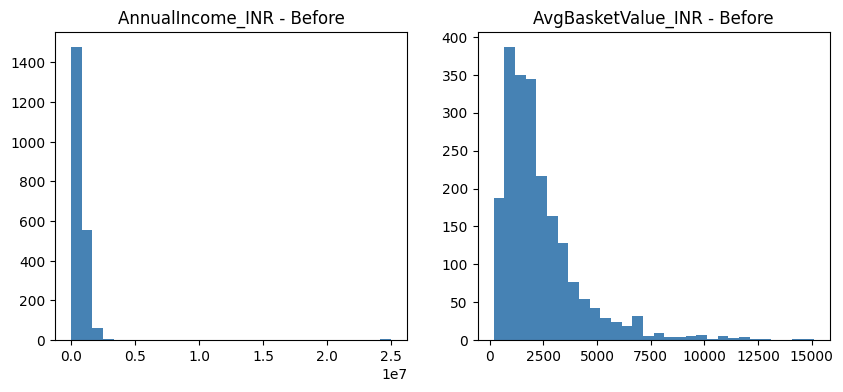

In [49]:
#BEFORE
print("BEFORE:")
print(cusDS[['AnnualIncome_INR', 'AvgBasketValue_INR']].describe())
print("\nSkewness:")
print("AnnualIncome_INR:", cusDS['AnnualIncome_INR'].skew())
print("AvgBasketValue_INR:", cusDS['AvgBasketValue_INR'].skew())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(cusDS['AnnualIncome_INR'], bins=30, color='steelblue')
axes[0].set_title('AnnualIncome_INR - Before')

axes[1].hist(cusDS['AvgBasketValue_INR'], bins=30, color='steelblue')
axes[1].set_title('AvgBasketValue_INR - Before')

**Transformation**

In [50]:
cusDS['AnnualIncome_INR_log'] = np.log1p(cusDS['AnnualIncome_INR'])
cusDS['AvgBasketValue_INR_log'] = np.log1p(cusDS['AvgBasketValue_INR'])

In [51]:
cusDS = cusDS.drop(columns=['AnnualIncome_INR', 'AvgBasketValue_INR'])

**After**


AFTER:
       AnnualIncome_INR_log  AvgBasketValue_INR_log
count           2109.000000             2109.000000
mean              13.342519                7.504409
std                0.875432                0.716701
min                0.693147                5.161352
25%               13.041045                7.030725
50%               13.382607                7.505512
75%               13.721482                7.978897
max               17.034386                9.622731

Skewness:
AnnualIncome_INR_log: -8.439000343607724
AvgBasketValue_INR_log: 7.767943775421866e-05


Text(0.5, 1.0, 'AvgBasketValue_INR - After Log')

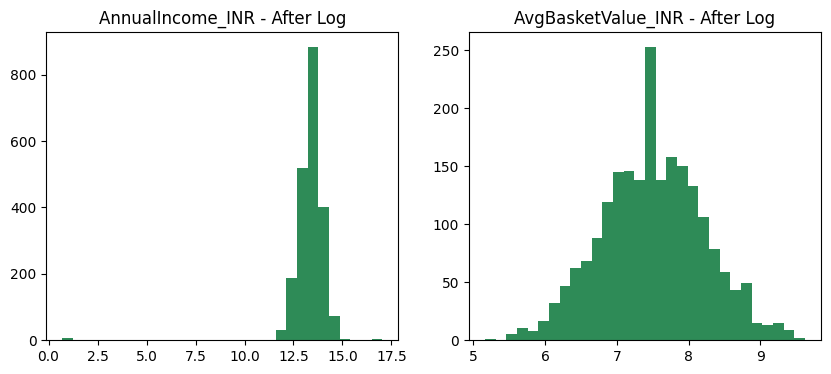

In [52]:
print("\nAFTER:")
print(cusDS[['AnnualIncome_INR_log', 'AvgBasketValue_INR_log']].describe())
print("\nSkewness:")
print("AnnualIncome_INR_log:", cusDS['AnnualIncome_INR_log'].skew())
print("AvgBasketValue_INR_log:", cusDS['AvgBasketValue_INR_log'].skew())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(cusDS['AnnualIncome_INR_log'], bins=30, color='seagreen')
axes[0].set_title('AnnualIncome_INR - After Log')
axes[1].hist(cusDS['AvgBasketValue_INR_log'], bins=30, color='seagreen')
axes[1].set_title('AvgBasketValue_INR - After Log')

## 4.2 Label Encoding for MembershipTier

**Before**

In [53]:
# BEFORE
print("BEFORE:")
print(cusDS['MembershipTier'].value_counts())
print(cusDS['VisitFrequency'].value_counts())
print(cusDS[['MembershipTier', 'VisitFrequency']].head())

BEFORE:
MembershipTier
Silver      821
Platinum    467
Basic       412
Gold        409
Name: count, dtype: int64
VisitFrequency
Rarely     794
Monthly    547
Weekly     515
Daily      253
Name: count, dtype: int64
  MembershipTier VisitFrequency
0         Silver         Rarely
1           Gold         Weekly
2         Silver         Rarely
3         Silver         Rarely
4          Basic        Monthly


**Transformation**

In [54]:
tier_order = {'Basic': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
cusDS['MembershipTier_encoded'] = cusDS['MembershipTier'].map(tier_order)

visit_order = {'Rarely': 0, 'Monthly': 1, 'Weekly': 2, 'Daily': 3}
cusDS['VisitFrequency_encoded'] = cusDS['VisitFrequency'].map(visit_order)

In [55]:
cusDS = cusDS.drop(columns=['MembershipTier', 'VisitFrequency'])

**After**

In [56]:
print("\nAFTER:")
print(cusDS['MembershipTier_encoded'].value_counts())
print(cusDS['VisitFrequency_encoded'].value_counts())
print(cusDS[['MembershipTier_encoded', 'VisitFrequency_encoded']].head())


AFTER:
MembershipTier_encoded
1    821
3    467
0    412
2    409
Name: count, dtype: int64
VisitFrequency_encoded
0    794
1    547
2    515
3    253
Name: count, dtype: int64
   MembershipTier_encoded  VisitFrequency_encoded
0                       1                       0
1                       2                       2
2                       1                       0
3                       1                       0
4                       0                       1


## 4.3 One-Hot Encoding for nominal categorical columns

In [57]:
nominal_cols = ['Gender', 'PreferredCategory', 'DeviceType', 'PaymentMethod', 'IncomeCurrency', 'CouponUsed', 'City']

**Before**

In [58]:
print("BEFORE:")
print("Shape:", cusDS.shape)
print(cusDS[nominal_cols].head())

BEFORE:
Shape: (2109, 26)
   Gender PreferredCategory DeviceType PaymentMethod IncomeCurrency  \
0  Female            Beauty    Android   Credit Card            INR   
1    Male            Sports        iOS           Upi            INR   
2    Male       Electronics     Mobile           Upi            INR   
3  Female        Food Court    Android   Credit Card            INR   
4    Male           Fashion        Web   Credit Card            INR   

  CouponUsed       City  
0        Yes  Bengaluru  
1        Yes       Pune  
2        Yes    Lucknow  
3        Yes       Pune  
4        Yes  Bengaluru  


**Transformation**

In [59]:
# One-hot encode
cusDS = pd.get_dummies(cusDS, columns=nominal_cols, prefix=nominal_cols)

In [60]:
onehot_cols = [col for col in cusDS.columns if any(
    col.startswith(prefix) for prefix in
    ['Gender_', 'PreferredCategory_', 'DeviceType_', 'PaymentMethod_', 'IncomeCurrency_', 'CouponUsed_', 'City_']
)]

cusDS[onehot_cols] = cusDS[onehot_cols].astype(int)

**After**

In [61]:
print("\nAFTER:")
print("Shape:", cusDS.shape)
cusDS[cusDS.columns.tolist()[19:]].head()


AFTER:
Shape: (2109, 58)


,Gender_Female,Gender_Male,Gender_Other,PreferredCategory_Beauty,PreferredCategory_Books,PreferredCategory_Electronics,PreferredCategory_Fashion,PreferredCategory_Food Court,PreferredCategory_Gaming,PreferredCategory_Grocery,PreferredCategory_Home Decor,PreferredCategory_Kids,PreferredCategory_Sports,DeviceType_Android,DeviceType_Desktop,DeviceType_Mobile,DeviceType_Web,DeviceType_iOS,PaymentMethod_Card,PaymentMethod_Cash,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Upi,PaymentMethod_Wallet,IncomeCurrency_INR,IncomeCurrency_USD,CouponUsed_No,CouponUsed_Yes,City_Ahmedabad,City_Bangalore,City_Bengaluru,City_Chennai,City_Delhi,City_Hyderabad,City_Jaipur,City_Kolkata,City_Lucknow,City_Mumbai,City_Pune
0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1
2,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0


## 4.4 Min-Max Normalization for SpendingScore_1_100 and SatisfactionRating_1_5

In [62]:
from sklearn.preprocessing import MinMaxScaler
cols_to_normalize = ['SpendingScore_1_100', 'SatisfactionRating_1_5']

**Before**

In [63]:
print("BEFORE:")
print(cusDS[cols_to_normalize].describe())

BEFORE:
       SpendingScore_1_100  SatisfactionRating_1_5
count          2109.000000             2109.000000
mean             53.935514                3.043148
std              21.470482                1.401929
min               1.000000                1.000000
25%              39.000000                2.000000
50%              54.000000                3.000000
75%              68.000000                4.000000
max             100.000000                5.000000


**Transformation**

In [64]:
scaler = MinMaxScaler()
cusDS[[c + '_minmax' for c in cols_to_normalize]] = scaler.fit_transform(cusDS[cols_to_normalize])
cusDS = cusDS.drop(columns=['SpendingScore_1_100', 'SatisfactionRating_1_5'])

**After**

In [65]:
print("\nAFTER:")
print(cusDS[[c + '_minmax' for c in cols_to_normalize]].describe())


AFTER:
       SpendingScore_1_100_minmax  SatisfactionRating_1_5_minmax
count                 2109.000000                    2109.000000
mean                     0.534702                       0.510787
std                      0.216874                       0.350482
min                      0.000000                       0.000000
25%                      0.383838                       0.250000
50%                      0.535354                       0.500000
75%                      0.676768                       0.750000
max                      1.000000                       1.000000


## 4.5 Standardization (Z-score) for Age, TotalPurchases, LoyaltyPoints

In [66]:
from sklearn.preprocessing import StandardScaler
cols_to_standardize = ['Age', 'TotalPurchases', 'LoyaltyPoints']

**Before**

In [67]:
print("BEFORE:")
print(cusDS[cols_to_standardize].describe())

BEFORE:
               Age  TotalPurchases  LoyaltyPoints
count  2109.000000     2109.000000    2109.000000
mean     33.529635       17.477477    1187.690375
std      11.291955       17.355122     616.755855
min       0.000000        0.000000       0.000000
25%      27.000000        5.000000     751.000000
50%      33.000000       12.000000    1189.000000
75%      41.000000       25.000000    1597.000000
max      75.000000      124.000000    2955.000000


**Transformation**

In [68]:
scaler = StandardScaler()
cusDS[[c + '_standardized' for c in cols_to_standardize]] = scaler.fit_transform(cusDS[cols_to_standardize])
cusDS = cusDS.drop(columns=['Age', 'TotalPurchases', 'LoyaltyPoints'])

**After**

In [69]:
print("\nAFTER:")
print(cusDS[[c + '_standardized' for c in cols_to_standardize]].describe())


AFTER:
       Age_standardized  TotalPurchases_standardized  \
count      2.109000e+03                 2.109000e+03   
mean      -1.861427e-16                -5.053647e-17   
std        1.000237e+00                 1.000237e+00   
min       -2.970042e+00                -1.007289e+00   
25%       -5.783926e-01                -7.191212e-01   
50%       -4.691486e-02                -3.156864e-01   
75%        6.617221e-01                 4.335496e-01   
max        3.673429e+00                 6.139270e+00   

       LoyaltyPoints_standardized  
count                2.109000e+03  
mean                 6.738196e-17  
std                  1.000237e+00  
min                 -1.926163e+00  
25%                 -7.082121e-01  
50%                  2.123913e-03  
75%                  6.638067e-01  
max                  2.866173e+00  


**Final Shape After Transformations**

In [70]:
print("AFTER:")
print("Shape:", cusDS.shape)
cusDS[:].head()

AFTER:
Shape: (2109, 58)


,CustomerID,CustomerName,JoinDate,LastPurchaseDate,OnlinePurchases,StorePurchases,Country,EmailProvider,ChurnNextMonth,HasPurchaseHistory,AnnualIncome_INR_log,AvgBasketValue_INR_log,MembershipTier_encoded,VisitFrequency_encoded,Gender_Female,Gender_Male,Gender_Other,PreferredCategory_Beauty,PreferredCategory_Books,PreferredCategory_Electronics,PreferredCategory_Fashion,PreferredCategory_Food Court,PreferredCategory_Gaming,PreferredCategory_Grocery,PreferredCategory_Home Decor,PreferredCategory_Kids,PreferredCategory_Sports,DeviceType_Android,DeviceType_Desktop,DeviceType_Mobile,DeviceType_Web,DeviceType_iOS,PaymentMethod_Card,PaymentMethod_Cash,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Upi,PaymentMethod_Wallet,IncomeCurrency_INR,IncomeCurrency_USD,CouponUsed_No,CouponUsed_Yes,City_Ahmedabad,City_Bangalore,City_Bengaluru,City_Chennai,City_Delhi,City_Hyderabad,City_Jaipur,City_Kolkata,City_Lucknow,City_Mumbai,City_Pune,SpendingScore_1_100_minmax,SatisfactionRating_1_5_minmax,Age_standardized,TotalPurchases_standardized,LoyaltyPoints_standardized
0,CUST100001,Diya Verma,2024-02-24,2024-09-14,3,38,India,gmail.com,0,1,12.393713,6.632568,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0.565657,0.25,0.750302,1.298053,0.405945
1,CUST100002,Aditya Nair,2025-02-02,2025-10-10,4,2,India,hotmail.com,0,1,13.942570,7.665416,2,2,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0.606061,0.00,1.636098,-0.603854,-0.523330
2,CUST100003,Saanvi Kumar,2022-05-30,2023-12-17,0,10,India,gmail.com,0,1,12.396118,7.727909,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0.636364,0.00,-0.578393,-0.488587,2.082857
3,CUST100004,Vihaan Iyer,2024-01-31,2024-07-18,29,1,India,gmail.com,0,1,13.060888,6.585716,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0.858586,0.50,-0.578393,0.721717,0.830849
4,CUST100005,Krishna Rao,2022-01-25,2022-05-01,21,17,India,hotmail.com,0,1,13.354861,9.397955,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0.525253,0.25,-0.755552,1.182786,0.024829


# Task 5 - Data Reduction

## 5.1 Correlation-based Feature Removal

**Before**

In [71]:
print("BEFORE:")
print("Shape:", cusDS.shape)

BEFORE:
Shape: (2109, 58)


**Finding Correlation**

In [72]:
# Correlation of all numeric/encoded columns with the target
numeric_cusDS = cusDS.select_dtypes(include=[np.number])
correlations = numeric_cusDS.corr()['ChurnNextMonth'].abs().sort_values(ascending=False)
print("\nCorrelation with ChurnNextMonth:")
print(correlations)


Correlation with ChurnNextMonth:
ChurnNextMonth                   1.000000
SpendingScore_1_100_minmax       0.149193
TotalPurchases_standardized      0.063132
OnlinePurchases                  0.062259
PaymentMethod_Cash               0.052295
DeviceType_Mobile                0.043250
StorePurchases                   0.042626
PaymentMethod_Upi                0.034032
City_Mumbai                      0.032138
DeviceType_Desktop               0.031950
City_Pune                        0.028816
PaymentMethod_Wallet             0.026444
City_Bangalore                   0.025270
LoyaltyPoints_standardized       0.023980
PaymentMethod_Card               0.023374
DeviceType_Android               0.021967
PreferredCategory_Books          0.021721
City_Hyderabad                   0.021689
PreferredCategory_Grocery        0.020886
Gender_Male                      0.018743
CouponUsed_No                    0.018685
CouponUsed_Yes                   0.018685
PreferredCategory_Sports         0.018653


*Correlation analysis reveals that no individual feature has a strong linear relationship with the target variable ChurnNextMonth; the highest correlation (SpendingScore_1_100, r≈0.15) is weak by conventional standards.*<br>
***This suggests either:***<br>


1.   Churn is driven by more complex, non-linear interactions between features rather than any single strong predictor
2.   The synthetic/noisy nature of this dataset limits the strength of individual feature-target relationships.<br>

*This has implications for model choice, tree-based models (which capture non-linear interactions) may outperform simple linear models here.*




**We Drop the Attributes with Correlation < 0.01**<br>
Features with absolute correlation below 0.01 against ChurnNextMonth were removed as a conservative correlation-based filter, targeting only near-zero-signal columns

In [73]:
cols_to_drop = correlations[(correlations < 0.01) & (correlations.index != 'ChurnNextMonth')].index.tolist()
print(f"\nColumns to drop ({len(cols_to_drop)}):")
print(cols_to_drop)


Columns to drop (14):
['VisitFrequency_encoded', 'PreferredCategory_Food Court', 'Gender_Other', 'PreferredCategory_Fashion', 'City_Ahmedabad', 'PreferredCategory_Electronics', 'DeviceType_Web', 'PreferredCategory_Gaming', 'City_Chennai', 'MembershipTier_encoded', 'HasPurchaseHistory', 'AvgBasketValue_INR_log', 'PreferredCategory_Home Decor', 'SatisfactionRating_1_5_minmax']


In [74]:
cusDS = cusDS.drop(columns=cols_to_drop)

**After**

In [75]:
print("\nAFTER:")
print("Shape:", cusDS.shape)


AFTER:
Shape: (2109, 44)


**Reason for selecting Correlation-based Feature Removal:**<br>
*This technique was selected because our Task 2 and Task 4 analysis already revealed that most one-hot encoded categorical features (City, PreferredCategory, DeviceType, etc.) carry very little individual predictive relationship with the target variable ChurnNextMonth*<br>
We see that, the strongest correlation in the entire dataset was only 0.15.<br>
***Correlation-based removal directly targets this specific problem:***<br>


*   It identifies and removes features that contribute negligible linear signal, reducing dimensionality in a simple, interpretable way before applying a more powerful technique (PCA).

*It was preferred as our first reduction step because it requires no assumptions about feature relationships beyond pairwise correlation, and it lets us make an evidence-based, targeted cut rather than an arbitrary one*



## 5.2 PCA

In [76]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Exclude target, identifiers, and date columns
exclude_cols = ['ChurnNextMonth', 'CustomerID', 'CustomerName', 'JoinDate', 'LastPurchaseDate']
feature_cols = [c for c in cusDS.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

In [77]:
print("Number of features going into PCA:", len(feature_cols))

Number of features going into PCA: 37


**Applying PCA**

In [78]:
# Standardizing all features uniformly before PCA
X = cusDS[feature_cols]
X_scaled = StandardScaler().fit_transform(X)

# Fit PCA, keeping enough components to explain 90% variance
pca = PCA(n_components=0.90)
X_pca = pca.fit_transform(X_scaled)

**PCA Components & their explained variance**

In [79]:
print("Number of components retained:", X_pca.shape[1])
print("Total variance explained:", pca.explained_variance_ratio_.sum())
print("\nVariance explained per component:")
print(pca.explained_variance_ratio_)

Number of components retained: 27
Total variance explained: 0.9210199237801109

Variance explained per component:
[0.06039677 0.05640432 0.05339841 0.04947625 0.03940544 0.03844887
 0.03455515 0.03416786 0.03349145 0.03270565 0.032251   0.0312776
 0.03089707 0.0305914  0.03034165 0.03025546 0.02998035 0.02963026
 0.02905897 0.02851987 0.0280955  0.02769389 0.02705544 0.02676188
 0.02606355 0.02539757 0.02469828]


**Before**

In [80]:
print("BEFORE:")
print("Shape:", cusDS.shape)

BEFORE:
Shape: (2109, 44)


**Making Reduced Dataframe**

In [81]:
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=cusDS.index)

# Keep identifiers, dates, and target alongside the PCA components
cusDS_reduced = pd.concat([
    cusDS[['CustomerID', 'CustomerName', 'JoinDate', 'LastPurchaseDate', 'ChurnNextMonth']],
    pca_df
], axis=1)

**After**

In [82]:
print("\nAFTER:")
print("Shape:", cusDS_reduced.shape)
print(cusDS_reduced.head())


AFTER:
Shape: (2109, 32)
   CustomerID  CustomerName   JoinDate LastPurchaseDate  ChurnNextMonth  \
0  CUST100001    Diya Verma 2024-02-24       2024-09-14               0   
1  CUST100002   Aditya Nair 2025-02-02       2025-10-10               0   
2  CUST100003  Saanvi Kumar 2022-05-30       2023-12-17               0   
3  CUST100004   Vihaan Iyer 2024-01-31       2024-07-18               0   
4  CUST100005   Krishna Rao 2022-01-25       2022-05-01               0   

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  2.031136  0.422199  0.463127 -0.361194 -2.994041 -0.918283 -0.952426   
1 -0.504476  1.012126  1.775331  1.028332  1.639395  1.204930 -1.327403   
2 -0.488411  1.226689  1.218637  1.180175  0.723754  2.084657  1.105753   
3  1.269492  0.240598  1.258143 -0.873899 -2.578135  0.313944 -1.689306   
4  1.771378  1.152864  0.048007  1.888592 -1.250744 -0.674509 -0.807692   

        PC8       PC9      PC10      PC11      PC12      PC13      PC14 

**Reason for usiing PCA:**<br>
*The original 53 numeric/encoded features were replaced with 27 principal components, which together retain ~92% of the original variance. This substantially reduces dimensionality from 37(put in PCA) to 27(PCA) features while preserving the vast majority of information present in the data.*<br>
*The tradeoff is a loss of direct interpretability. Individual components are linear combinations of many original features and no longer correspond to a single named variable.*<br>

## Supplementary Check (Outside Task 5 Requirements): Testing Engineered Features

We will also test 2 Engineered Features, i.e 'customer_tenure' and 'recency_of_last_purchase', for their correlation with 'ChurnNextMonth'

In [83]:
customer_tenure = (cusDS['LastPurchaseDate'] - cusDS['JoinDate']).dt.days
recency_of_last_purchase = (cusDS["LastPurchaseDate"].max() - cusDS['LastPurchaseDate']).dt.days

print("Correlation of customer_tenure with ChurnNextMonth: ",np.abs(customer_tenure.corr(cusDS['ChurnNextMonth'])))
print("Correlation of recency_of_last_purchase with ChurnNextMonth: ",np.abs(recency_of_last_purchase.corr(cusDS['ChurnNextMonth'])))

Correlation of customer_tenure with ChurnNextMonth:  0.005856426929161567
Correlation of recency_of_last_purchase with ChurnNextMonth:  0.0052015093449404685


**Reason for testing Engineered Features and its Results:**<br>
PCA introduced interpretability trade-offs by compressing features into components that no longer map to named business variables. As a check, we tested whether engineered features like customer_tenure and recency_of_last_purchase, could have replaced any PCA components with something more interpretable.<br>
However both showed negligible correlation with ChurnNextMonth (-0.006 and -0.005 respectively), meaning they carry effectively no predictive signal and could not meaningfully substitute for any PCA component.

**Final Reduced Components:**<br>
Our Reduced DataFrame consists of: 27(PCA Components)+2(Identifiers)+2(Date)+1(Target) = 32(Total) Features.

# Task 6 - Proximity Measures

## 6.1 Selecting 20 records

In [84]:
sample_20 = cusDS_reduced.sample(n=20, random_state=42).reset_index(drop=True)
print(sample_20[['CustomerID']])

pca_cols = [c for c in cusDS_reduced.columns if c.startswith('PC')]
X_sample = sample_20[pca_cols].values

      CustomerID
0     CUST100458
1     CUST101248
2     CUST101496
3     CUST100583
4     CUST100426
5     CUST100259
6     CUST100548
7     CUST101897
8     CUST101779
9     CUST100711
10    CUST101782
11    CUST101226
12    CUST101744
13    CUST100943
14    CUST102126
15    CUST100071
16    CUST101207
17    CUST100872
18  CUST_NEW0027
19    CUST100437


## 6.2 Euclidean Distance

In [85]:
from sklearn.metrics.pairwise import euclidean_distances

euclidean_matrix = euclidean_distances(X_sample)
euclidean_df = pd.DataFrame(euclidean_matrix, index=sample_20['CustomerID'], columns=sample_20['CustomerID'])


**Euclidean Distance Matrix**

In [86]:
euclidean_df

CustomerID,CUST100458,CUST101248,CUST101496,CUST100583,CUST100426,CUST100259,CUST100548,CUST101897,CUST101779,CUST100711,CUST101782,CUST101226,CUST101744,CUST100943,CUST102126,CUST100071,CUST101207,CUST100872,CUST_NEW0027,CUST100437
CustomerID,,,,,,,,,,,,,,,,,,,,
CUST100458,0.000000,8.284885,8.775128,7.999324,6.469353,8.074401,9.848641,7.589222,7.707200,8.259099,7.511156,7.069168,6.057722,7.262405,11.098193,7.945220,6.590556,7.104789,9.313269,7.362019
CUST101248,8.284885,0.000000,8.654961,8.196920,6.829573,8.862389,10.397186,8.956452,9.091482,6.381253,9.615885,8.374683,8.372953,7.572776,9.550597,10.068221,8.856515,8.428088,9.008663,7.599102
CUST101496,8.775128,8.654961,0.000000,9.080191,8.870494,7.616682,9.947031,9.472377,9.357896,9.194756,10.067084,10.316732,9.297653,8.494095,11.754296,10.105394,9.169594,9.785854,8.329821,4.672654
CUST100583,7.999324,8.196920,9.080191,0.000000,6.686582,7.416409,8.896193,7.221773,9.096865,8.760364,9.824302,7.883043,7.993636,7.227350,11.238070,7.444924,7.794368,6.398931,8.460064,7.561922
CUST100426,6.469353,6.829573,8.870494,6.686582,0.000000,6.260239,9.346940,5.683357,6.758496,7.627409,8.568647,6.554676,5.066262,5.964820,10.580994,6.449798,4.920314,6.180781,6.992650,6.939724
CUST100259,8.074401,8.862389,7.616682,7.416409,6.260239,0.000000,10.329820,8.357911,8.621614,8.982248,9.552877,8.635849,7.079781,7.827742,10.995687,8.622672,7.510550,7.583224,8.029769,5.772019
CUST100548,9.848641,10.397186,9.947031,8.896193,9.346940,10.329820,0.000000,8.864237,10.786015,9.569489,10.236080,10.605038,10.498590,9.059444,12.376992,8.517202,8.967029,9.614460,8.634846,9.865609
CUST101897,7.589222,8.956452,9.472377,7.221773,5.683357,8.357911,8.864237,0.000000,8.114234,8.417159,9.197158,8.999762,7.876947,6.665216,11.770576,5.566158,6.252552,8.026017,8.725959,7.615584
CUST101779,7.707200,9.091482,9.357896,9.096865,6.758496,8.621614,10.786015,8.114234,0.000000,8.682786,9.713291,9.485580,8.326123,5.297004,12.624394,9.254891,7.783819,8.636095,8.329265,8.077990


## 6.3 Cosine Similarity

In [87]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_matrix = cosine_similarity(X_sample)
cosine_df = pd.DataFrame(cosine_matrix, index=sample_20['CustomerID'], columns=sample_20['CustomerID'])

**Cosine Similarity Matrix**

In [88]:
cosine_df

CustomerID,CUST100458,CUST101248,CUST101496,CUST100583,CUST100426,CUST100259,CUST100548,CUST101897,CUST101779,CUST100711,CUST101782,CUST101226,CUST101744,CUST100943,CUST102126,CUST100071,CUST101207,CUST100872,CUST_NEW0027,CUST100437
CustomerID,,,,,,,,,,,,,,,,,,,,
CUST100458,1.000000,-0.093392,0.021794,-0.038150,0.023077,-0.066918,-0.119241,0.045047,0.120993,-0.073058,0.235411,0.229661,0.351267,-0.004362,-0.087505,0.078353,0.186816,0.113085,-0.357807,0.081419
CUST101248,-0.093392,1.000000,0.100582,-0.016540,0.013660,-0.197968,-0.186346,-0.238736,-0.149153,0.401539,-0.190752,-0.013062,-0.149960,-0.006721,0.258500,-0.391985,-0.361520,-0.158227,-0.186507,0.090173
CUST101496,0.021794,0.100582,1.000000,-0.006043,-0.300394,0.294526,0.079931,-0.115764,0.002819,-0.007704,-0.082474,-0.254105,-0.130001,0.010143,-0.026148,-0.151597,-0.150225,-0.249984,0.179374,0.748093
CUST100583,-0.038150,-0.016540,-0.006043,1.000000,0.032540,0.146146,0.130737,0.180241,-0.169442,-0.147384,-0.262777,0.087339,-0.067763,0.065129,-0.081201,0.228373,-0.072873,0.321027,-0.064291,0.082352
CUST100426,0.023077,0.013660,-0.300394,0.032540,1.000000,0.152483,-0.280170,0.302379,0.136891,-0.234693,-0.319761,0.141969,0.396885,0.038523,-0.191987,0.243750,0.374498,0.080995,-0.011830,-0.117126
CUST100259,-0.066918,-0.197968,0.294526,0.146146,0.152483,1.000000,-0.194468,-0.107269,-0.058085,-0.215965,-0.201980,-0.104159,0.155589,-0.109533,-0.035324,-0.044400,-0.004885,0.036661,0.033665,0.460989
CUST100548,-0.119241,-0.186346,0.079931,0.130737,-0.280170,-0.194468,1.000000,0.124538,-0.212028,0.009611,-0.025832,-0.207250,-0.311340,-0.009617,-0.070356,0.259154,0.024073,-0.083188,0.202979,-0.113885
CUST101897,0.045047,-0.238736,-0.115764,0.180241,0.302379,-0.107269,0.124538,1.000000,0.052502,-0.080762,-0.125391,-0.213843,-0.060246,0.186661,-0.214687,0.563714,0.295874,-0.094027,-0.155268,0.048928
CUST101779,0.120993,-0.149153,0.002819,-0.169442,0.136891,-0.058085,-0.212028,0.052502,1.000000,-0.036492,-0.144406,-0.217147,-0.055827,0.561857,-0.312914,-0.103978,0.031685,-0.130541,0.051021,0.042968


## 6.4 Interpretation - Which customers are most similar?

Digonal values are similarities with self, and hence afee not considered


Text(0.5, 1.0, 'Cosine Similarity Heatmap (Higher Value = more similar)')

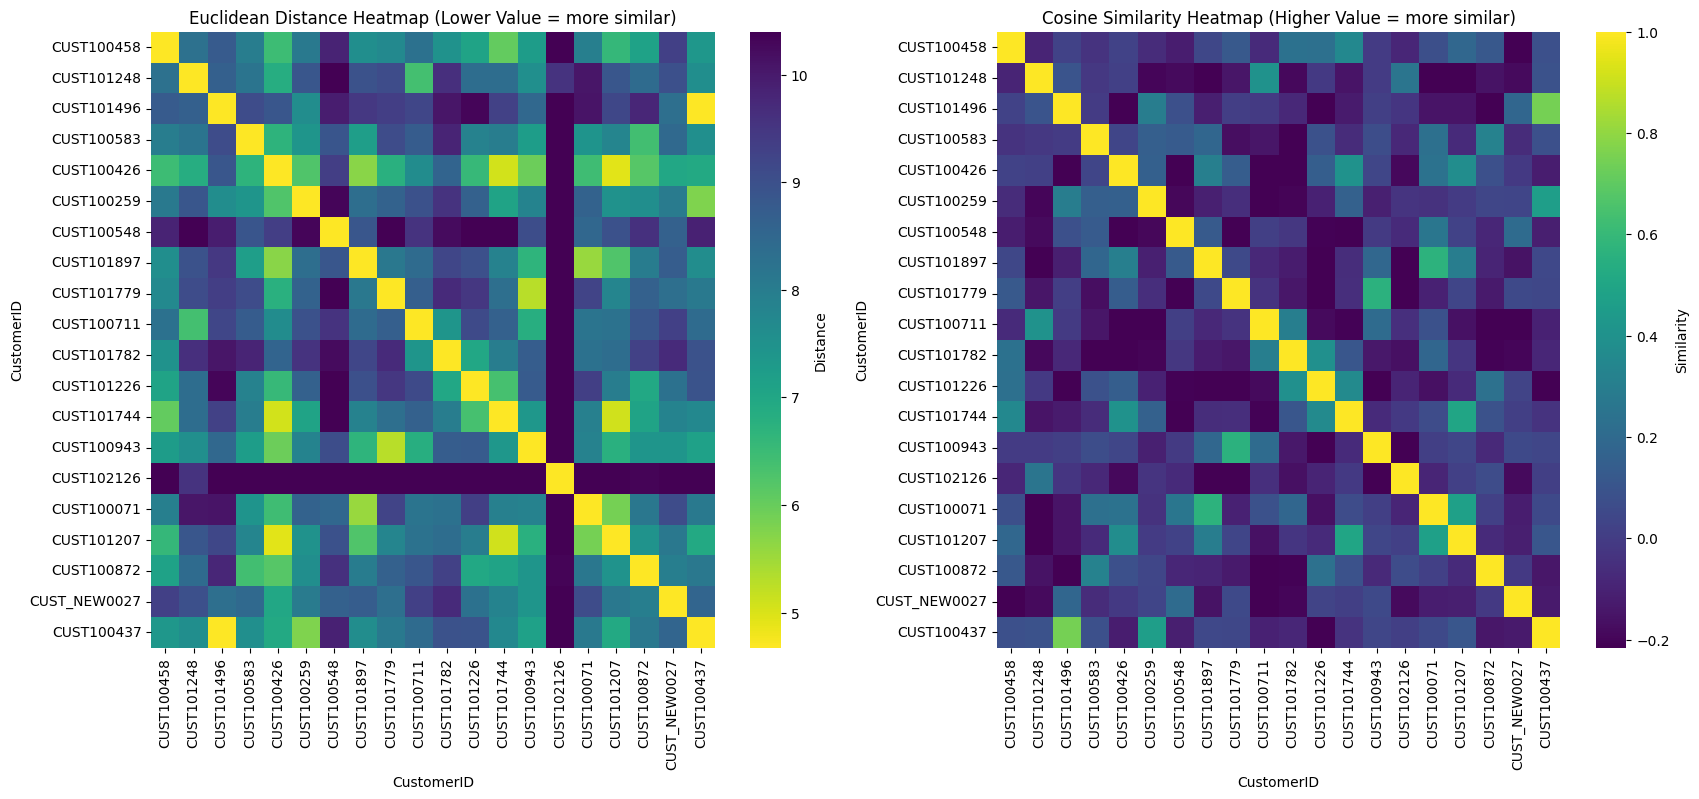

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

print("Digonal values are similarities with self, and hence afee not considered")
sns.heatmap(euclidean_df, annot=False, cmap='viridis_r', ax=axes[0],
            vmin=euclidean_df.values[euclidean_df.values > 0].min(),
            vmax=np.percentile(euclidean_df.values, 90),  # clip extreme outlier influence
            xticklabels=True, yticklabels=True, cbar_kws={'label': 'Distance'})
axes[0].set_title('Euclidean Distance Heatmap (Lower Value = more similar)')

sns.heatmap(cosine_df, annot=False, cmap='viridis', ax=axes[1],
            vmin=np.percentile(cosine_df.values[cosine_df.values < 1], 10),
            vmax=cosine_df.values[cosine_df.values < 1].max(),  # clip extreme outlier influence
            xticklabels=True, yticklabels=True, cbar_kws={'label': 'Similarity'})
axes[1].set_title('Cosine Similarity Heatmap (Higher Value = more similar)')

**Most similar by Euclidean Distance**

In [90]:
euclidean_no_self = euclidean_df.copy()
euclidean_arr = euclidean_no_self.to_numpy(copy=True)
np.fill_diagonal(euclidean_arr, np.inf) # to ignore self-distance
min_pair_idx = np.unravel_index(euclidean_arr.argmin(), euclidean_arr.shape)
print("Most similar pair (Euclidean - smallest distance):",
      euclidean_df.index[min_pair_idx[0]], "&", euclidean_df.columns[min_pair_idx[1]],
      "| Distance:", euclidean_arr.min())

Most similar pair (Euclidean - smallest distance): CUST101496 & CUST100437 | Distance: 4.672653931247567


**Most Similar by Cosine Similarity**

In [91]:
cosine_no_self = cosine_df.copy()
cosine_arr = cosine_no_self.to_numpy(copy=True)
np.fill_diagonal(cosine_arr, -np.inf)  # to ignore self-similarity
max_pair_idx = np.unravel_index(cosine_arr.argmax(), cosine_arr.shape)
print("Most similar pair (Cosine - highest similarity):",
      cosine_df.index[max_pair_idx[0]], "&", cosine_df.columns[max_pair_idx[1]],
      "| Similarity:", cosine_arr.max())

Most similar pair (Cosine - highest similarity): CUST101496 & CUST100437 | Similarity: 0.7480933720118523


Most Similar Customers from the 20 records:

In [92]:
similar = ['CUST101496','CUST100437']
cusDS_reduced.loc[cusDS_reduced['CustomerID'].isin(similar),["CustomerID","CustomerName"]]

,CustomerID,CustomerName
420,CUST100437,Kiara Kumar
1429,CUST101496,Aadhya Khan


# Task 7 - Reflection Report

**Major Preprocessing Challenges**<br>
The customer dataset presented several overlapping data quality problems rather than one dominant issue. Missing values were widespread (up to 16% in columns like Country), but the more difficult challenge was distinguishing genuine data entry errors from structurally meaningful patterns. For example, duplicate CustomerIDs turned out to be two different problems: 64 rows were true redundant duplicates, while 93 rows were “ID collisions”, the same ID mistakenly assigned to two entirely different customers. Treating these identically would have either lost real customer records or left corrupted IDs in place.<br>
Categorical inconsistency was another significant issue; eleven columns contained the same category represented in different spellings, casings, or encodings depending on the source system. Gender, for instance, appeared as MALE, male, M, and Male within the same column, while MembershipTier included variants such as Silvr, silver, and PLATINUM. The numerical columns presented a different problem as several contained placeholder values such as 99999999 and 999999, which initially appeared to be statistical outliers but after inspection it was seen that these were not genuine extreme values but invalid entries that had been mistaken for real data. Date fields added a further complication. JoinDate and LastPurchaseDate were both stored as text, but in inconsistent formats, which meant the data had to be parsed carefully before any date-based logic could be relied upon, otherwise, inconsistencies such as purchases recorded before a customer's join date would have gone unnoticed.

**Step With the Greatest Impact**<br>
Resolving invalid entries and sentinel values had the single greatest impact. Because these corrupted values inflated statistics (maximums, standard deviations) and were disguised as outliers. Cleaning them changed the shape of nearly every numerical column and directly affected which columns later showed meaningful correlation with churn. Categorical standardization was a close second, because without it, one-hot encoding would have fragmented single categories (e.g., “Chennai”) into a dozen columns, diluting any real signal those features carried.

**Problems That Remained**<br>
Even after cleaning, every individual feature showed only weak linear correlation with ChurnNextMonth (the strongest was approximately 0.15). This suggests churn is driven by non-linear interactions between features rather than any single strong predictor, and it may partly reflect the synthetic, noisy origin of the dataset. As a further check, two engineered features often strongly predictive in real churn analysis that is, the customer tenure and recency of last purchase were tested against the target and also showed negligible correlation (-0.006 and −0.005 respectively), reinforcing that the weak signal is a property of the dataset itself rather than a gap in feature representation. Some ambiguity was also left unresolved by design. For instance, whether “Card” and “Credit Card” in PaymentMethod represent the same payment type. Country carried almost no variance after cleaning and offered little analytical value. PCA, while effective at reducing dimensionality, sacrificed interpretability, since the resulting 27 components no longer map to single named business variables, and the tested engineered features were not able to meaningfully substitute for any of them.

**Recommended Machine Learning Algorithm**<br>
Given how weak the linear correlations are, and the mix of numeric, ordinal, and one-hot encoded features involved, a tree-based ensemble models like, Random Forest or XGBoost makes more sense here than a linear model. These methods don't assume any particular shape of relationship with the target, so they can pick up on non-linear interactions between features, and they tend to handle mixed feature types without much fuss. They also produce feature importance rankings, which matters here, because the stakeholders will want to understand what's actually driving churn, not just get a prediction out of a black box, which is exactly what you'd end up with with a PCA-reduced linear model.

**Additional Preprocessing Before Deployment**<br>
Before production deployment, I would revisit the PaymentMethod ambiguity with domain input, validate the churn class balance (imputation and row-dropping may have shifted it), and, since the engineered temporal features tested here showed no relationship with churn, it might be good explore other domain-informed features or external data sources that might carry signal, which the current PCA components do not, for stakeholder-facing explanations. I would also establish data-quality monitoring at ingestion, so sentinel values and format inconsistencies are caught automatically before they reach the model, rather than discovered after the fact.